In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px

plt.style.use("ggplot")

In [2]:
import os

print(os.getcwd())

c:\Bluestock Fintech\mutual_fund_analytics\notebooks


In [3]:
import os

print(os.listdir())

['EDA_Analysis.ipynb']


In [4]:
import pandas as pd

nav = pd.read_csv("../data/raw/AXIS_nav.csv")

nav.head()

,date,nav
0,01-06-2026,6156.7532
1,29-05-2026,6151.1139
2,27-05-2026,6146.6118
3,26-05-2026,6144.0004
4,25-05-2026,6144.8478


In [5]:
nav.info()

<class 'pandas.DataFrame'>
RangeIndex: 3565 entries, 0 to 3564
Data columns (total 2 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   date    3565 non-null   str    
 1   nav     3565 non-null   float64
dtypes: float64(1), str(1)
memory usage: 90.6 KB


In [6]:
import pandas as pd
import glob
import os

files = glob.glob("../data/raw/*_nav.csv")

all_nav = []

for file in files:
    df = pd.read_csv(file)

    fund_house = os.path.basename(file).replace("_nav.csv", "")

    df["fund_house"] = fund_house

    all_nav.append(df)

nav_df = pd.concat(all_nav, ignore_index=True)

nav_df["date"] = pd.to_datetime(
    nav_df["date"],
    dayfirst=True
)

print(nav_df.shape)

print(nav_df["fund_house"].unique())

nav_df.head()

(19798, 3)
<ArrowStringArray>
['AXIS', 'HDFC', 'ICICI', 'KOTAK', 'NIPPON', 'SBI']
Length: 6, dtype: str


,date,nav,fund_house
0,2026-06-01,6156.7532,AXIS
1,2026-05-29,6151.1139,AXIS
2,2026-05-27,6146.6118,AXIS
3,2026-05-26,6144.0004,AXIS
4,2026-05-25,6144.8478,AXIS


In [7]:
print("Total Rows:", len(nav_df))
print("Fund Houses:", nav_df["fund_house"].nunique())

print(nav_df["date"].min())
print(nav_df["date"].max())

Total Rows: 19798
Fund Houses: 6
2012-12-31 00:00:00
2026-06-01 00:00:00


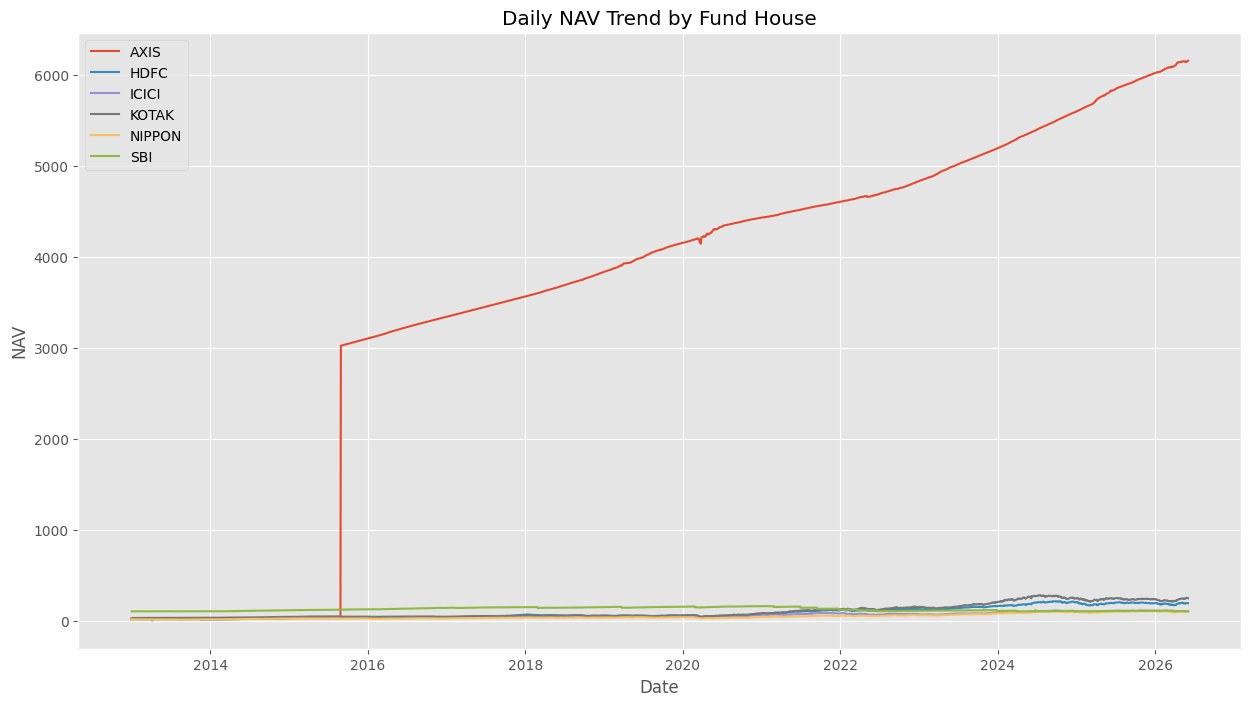

In [8]:
plt.figure(figsize=(15,8))

for fund in nav_df["fund_house"].unique():

    subset = nav_df[
        nav_df["fund_house"] == fund
    ]

    plt.plot(
        subset["date"],
        subset["nav"],
        label=fund
    )

plt.title("Daily NAV Trend by Fund House")
plt.xlabel("Date")
plt.ylabel("NAV")
plt.legend()

plt.show()

## Insight 1

AXIS fund exhibits significantly higher NAV values than all other fund houses throughout the period. The large gap suggests either exceptional long-term appreciation or a different NAV scaling methodology compared with peers.

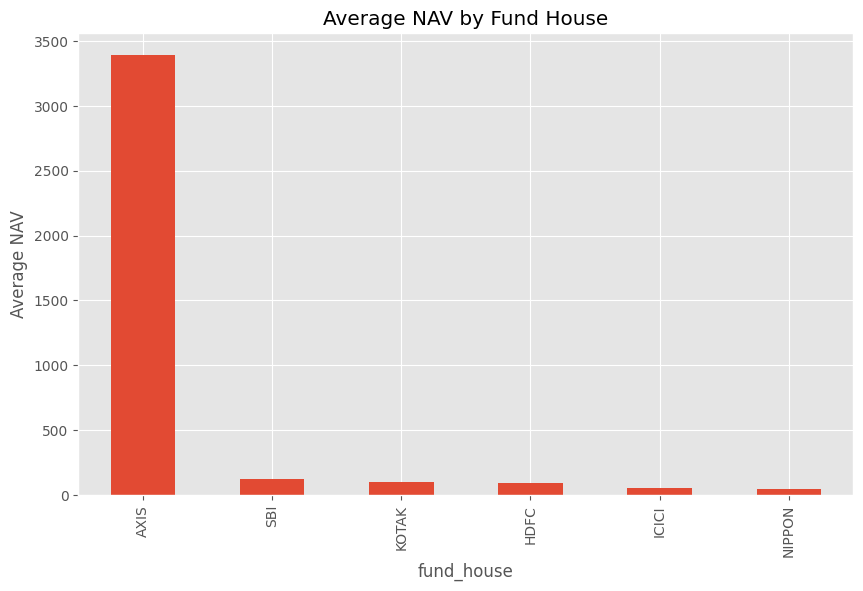

In [9]:
avg_nav = (
    nav_df.groupby("fund_house")["nav"]
    .mean()
    .sort_values(ascending=False)
)

plt.figure(figsize=(10,6))

avg_nav.plot(kind="bar")

plt.title("Average NAV by Fund House")
plt.ylabel("Average NAV")

plt.savefig(
    "../reports/avg_nav_comparison.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

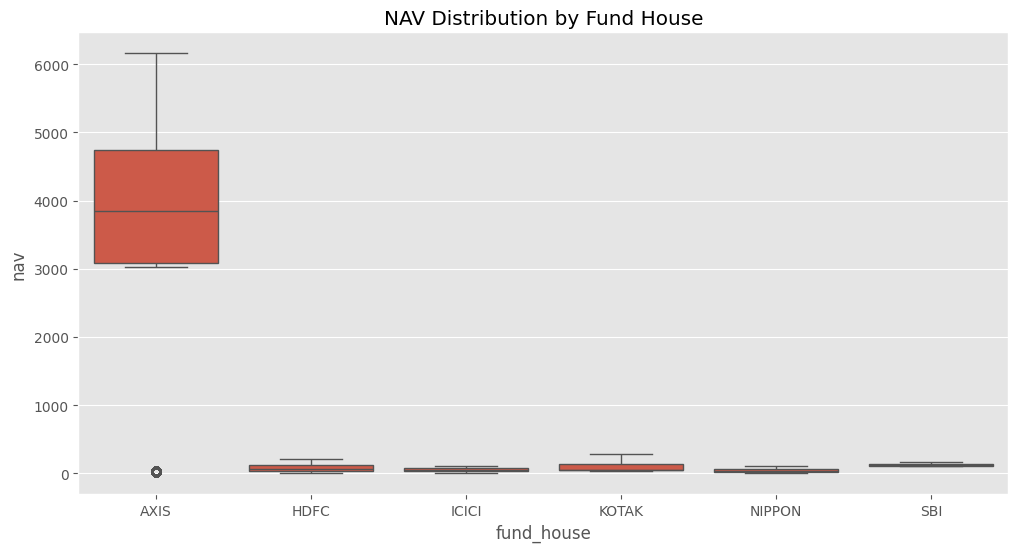

In [10]:
plt.figure(figsize=(12,6))

sns.boxplot(
    data=nav_df,
    x="fund_house",
    y="nav"
)

plt.title("NAV Distribution by Fund House")

plt.savefig(
    "../reports/nav_distribution.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [11]:
nav_df = nav_df.sort_values(
    ["fund_house","date"]
)

nav_df["daily_return"] = (
    nav_df.groupby("fund_house")["nav"]
    .pct_change()
)

nav_df.head()

,date,nav,fund_house,daily_return
3564,2012-12-31,23.9920,AXIS,NaN
3563,2013-01-01,23.9979,AXIS,0.000246
3562,2013-01-02,24.0036,AXIS,0.000238
3561,2013-01-03,24.0092,AXIS,0.000233
3560,2013-01-04,24.0147,AXIS,0.000229


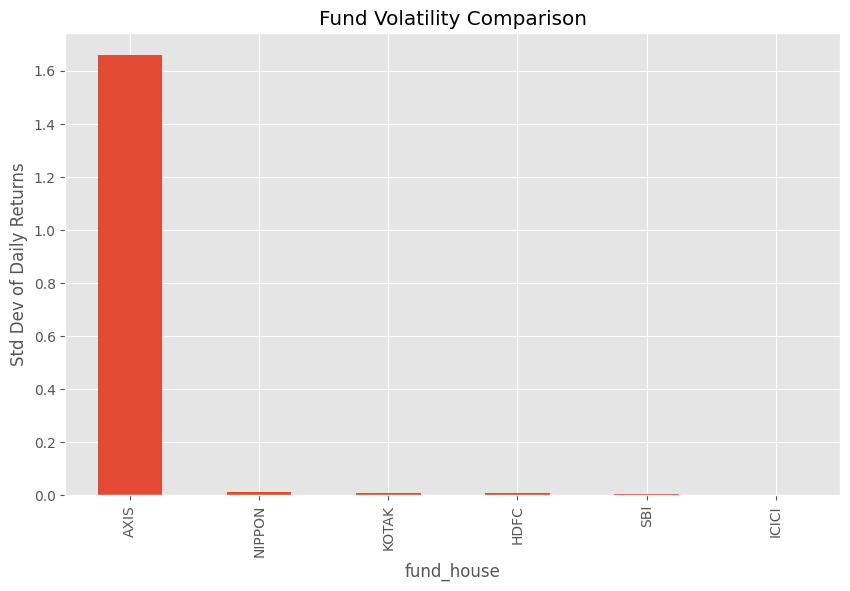

In [12]:
volatility = (
    nav_df.groupby("fund_house")["daily_return"]
    .std()
    .sort_values(ascending=False)
)

plt.figure(figsize=(10,6))

volatility.plot(kind="bar")

plt.title("Fund Volatility Comparison")
plt.ylabel("Std Dev of Daily Returns")

plt.savefig(
    "../reports/fund_volatility.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

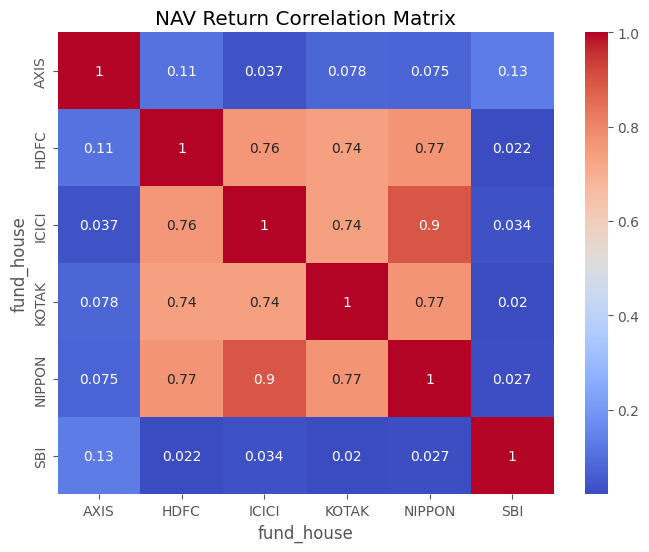

In [13]:
corr_df = nav_df.pivot_table(
    index="date",
    columns="fund_house",
    values="daily_return"
)

corr_matrix = corr_df.corr()

plt.figure(figsize=(8,6))

sns.heatmap(
    corr_matrix,
    annot=True,
    cmap="coolwarm"
)

plt.title("NAV Return Correlation Matrix")

plt.savefig(
    "../reports/correlation_matrix.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

## Insight 2

ICICI and NIPPON funds exhibit the strongest return correlation (0.90), indicating very similar NAV movement patterns. SBI shows the weakest correlation with other fund houses, suggesting relatively independent performance behavior.

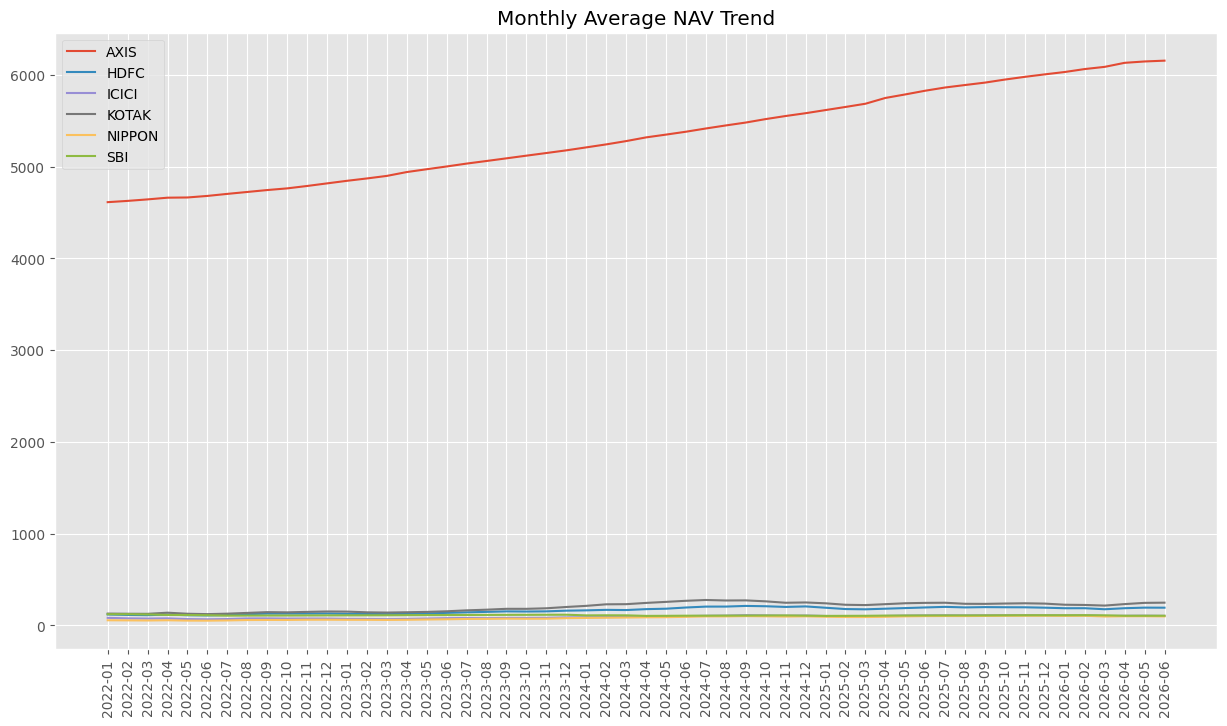

In [14]:
monthly_nav = nav_df.copy()
monthly_nav = monthly_nav[
    monthly_nav["date"] >= "2022-01-01"
]

monthly_nav["month"] = (
    monthly_nav["date"]
    .dt.to_period("M")
)

monthly_nav = (
    monthly_nav.groupby(
        ["month","fund_house"]
    )["nav"]
    .mean()
    .reset_index()
)

monthly_nav["month"] = (
    monthly_nav["month"]
    .astype(str)
)

plt.figure(figsize=(15,8))

for fund in monthly_nav["fund_house"].unique():

    subset = monthly_nav[
        monthly_nav["fund_house"] == fund
    ]

    plt.plot(
        subset["month"],
        subset["nav"],
        label=fund
    )

plt.xticks(rotation=90)

plt.title("Monthly Average NAV Trend")
plt.legend()

plt.savefig(
    "../reports/monthly_nav_trend.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [15]:
import plotly.express as px

fig = px.line(
    monthly_nav,
    x="month",
    y="nav",
    color="fund_house",
    title="NAV Trend Analysis (2022-2026)"
)

# 2023 Bull Run
fig.add_vrect(
    x0="2023-01-01",
    x1="2023-12-31",
    fillcolor="green",
    opacity=0.15,
    layer="below",
    line_width=0,
    annotation_text="2023 Bull Run"
)

# 2024 Correction
fig.add_vrect(
    x0="2024-03-01",
    x1="2024-06-30",
    fillcolor="red",
    opacity=0.15,
    layer="below",
    line_width=0,
    annotation_text="2024 Correction"
)

fig.show()

### Insight
NAVs across major fund houses showed a strong upward trend during the 2023 bull market. A temporary correction phase is visible during 2024 before the upward trend resumed.

In [16]:
print(monthly_nav["month"].min())
print(monthly_nav["month"].max())

2022-01
2026-06


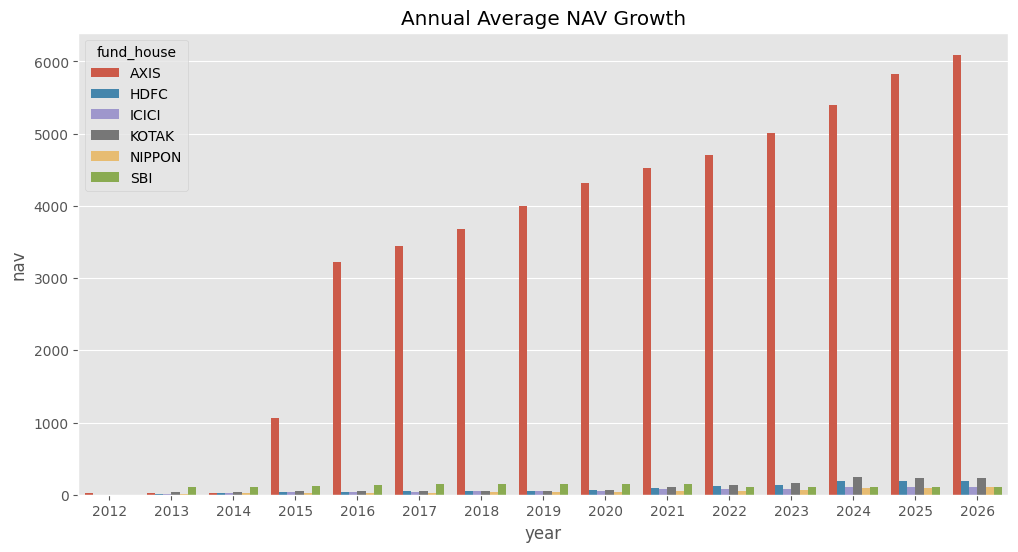

In [17]:
annual_nav = nav_df.copy()

annual_nav["year"] = annual_nav["date"].dt.year

annual_nav = (
    annual_nav.groupby(
        ["year","fund_house"]
    )["nav"]
    .mean()
    .reset_index()
)

plt.figure(figsize=(12,6))

sns.barplot(
    data=annual_nav,
    x="year",
    y="nav",
    hue="fund_house"
)

plt.title("Annual Average NAV Growth")

plt.savefig(
    "../reports/annual_nav_growth.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

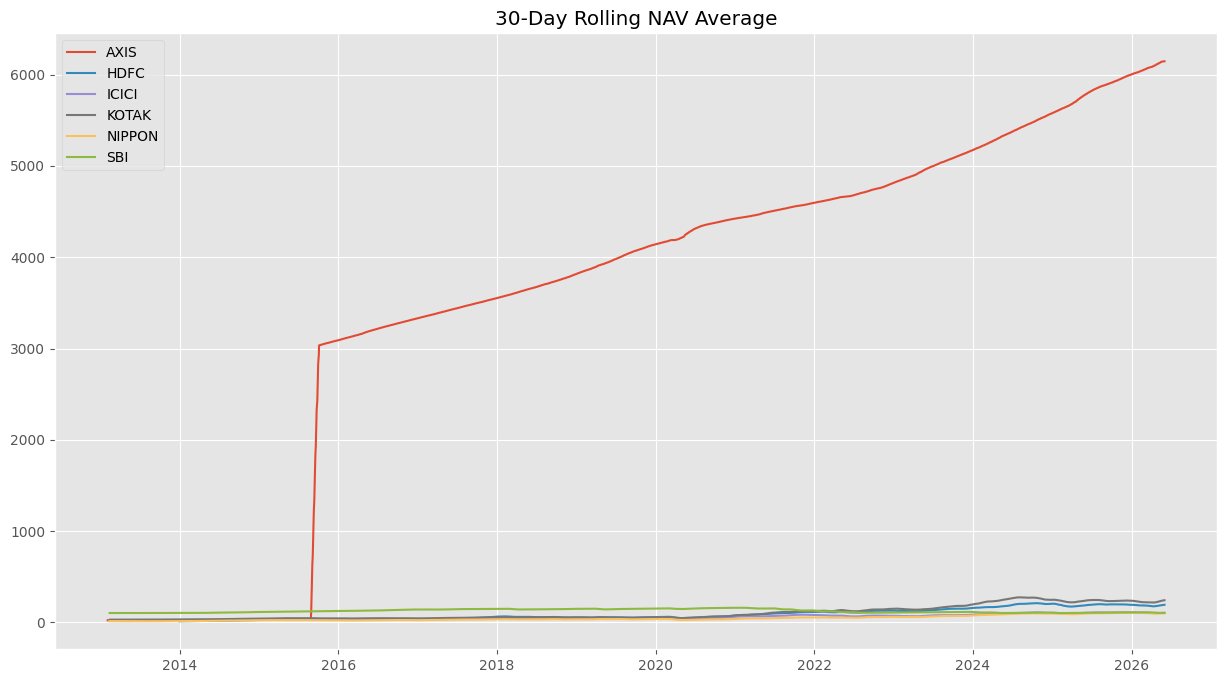

In [18]:
rolling_df = nav_df.copy()

rolling_df["rolling_30"] = (
    rolling_df.groupby("fund_house")["nav"]
    .transform(
        lambda x: x.rolling(30).mean()
    )
)

plt.figure(figsize=(15,8))

for fund in rolling_df["fund_house"].unique():

    subset = rolling_df[
        rolling_df["fund_house"] == fund
    ]

    plt.plot(
        subset["date"],
        subset["rolling_30"],
        label=fund
    )

plt.legend()

plt.title("30-Day Rolling NAV Average")

plt.savefig(
    "../reports/rolling_nav.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

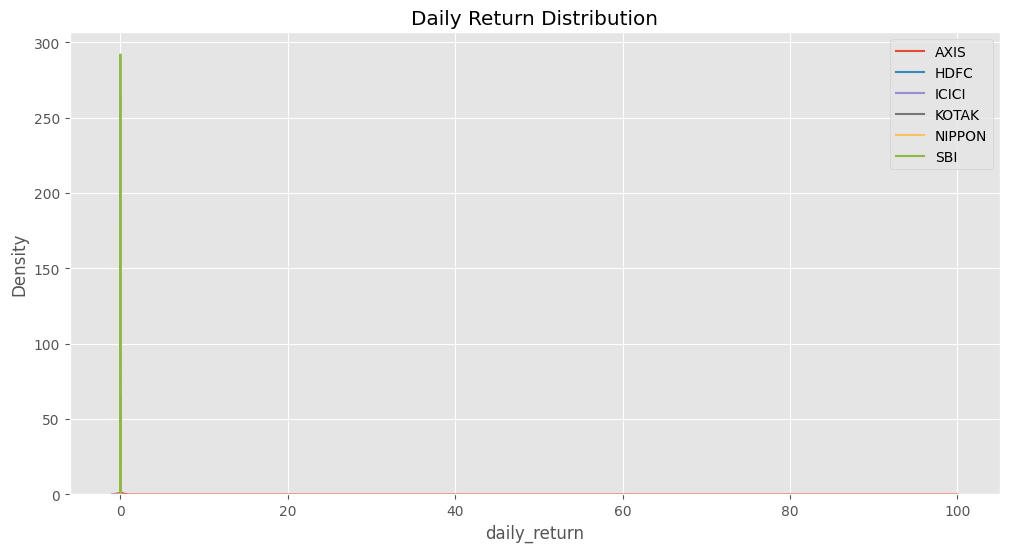

In [19]:
plt.figure(figsize=(12,6))

for fund in nav_df["fund_house"].unique():

    sns.kdeplot(
        nav_df[
            nav_df["fund_house"] == fund
        ]["daily_return"].dropna(),
        label=fund
    )

plt.legend()

plt.title("Daily Return Distribution")

plt.savefig(
    "../reports/return_distribution.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

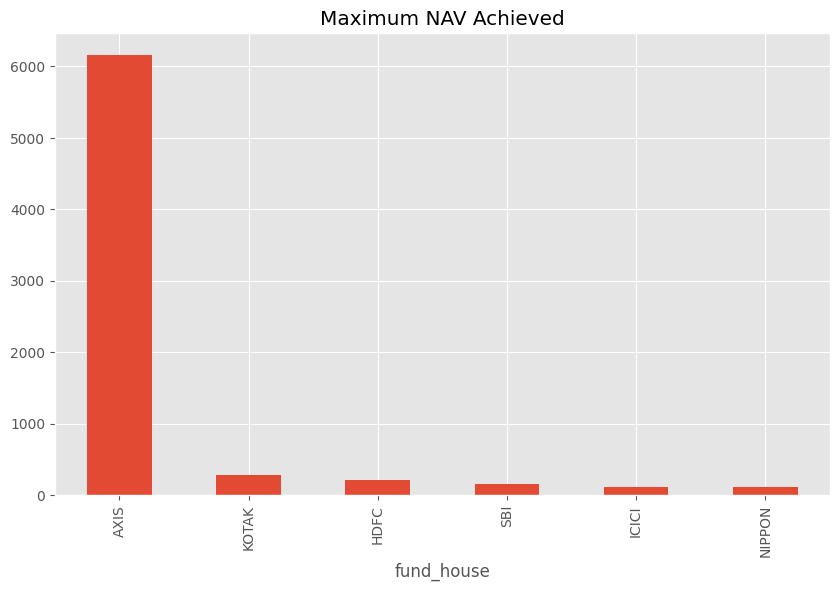

In [20]:
max_nav = (
    nav_df.groupby("fund_house")["nav"]
    .max()
    .sort_values(ascending=False)
)

plt.figure(figsize=(10,6))

max_nav.plot(kind="bar")

plt.title("Maximum NAV Achieved")

plt.savefig(
    "../reports/max_nav.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

## Insight 3

All fund houses demonstrate a long-term upward NAV trend, indicating sustained growth across the mutual fund industry during the study period.

## Insight 4

Monthly average NAV values show consistent appreciation over time, with stronger growth momentum after 2020.

## Insight 5

Rolling 30-day averages smooth short-term fluctuations and confirm long-term positive fund performance trends.

## Insight 6

Return distributions are centered around small daily changes, indicating relatively stable day-to-day fund movements.

## Insight 7

Maximum NAV analysis highlights significant differences in wealth creation across fund houses over the observation period.

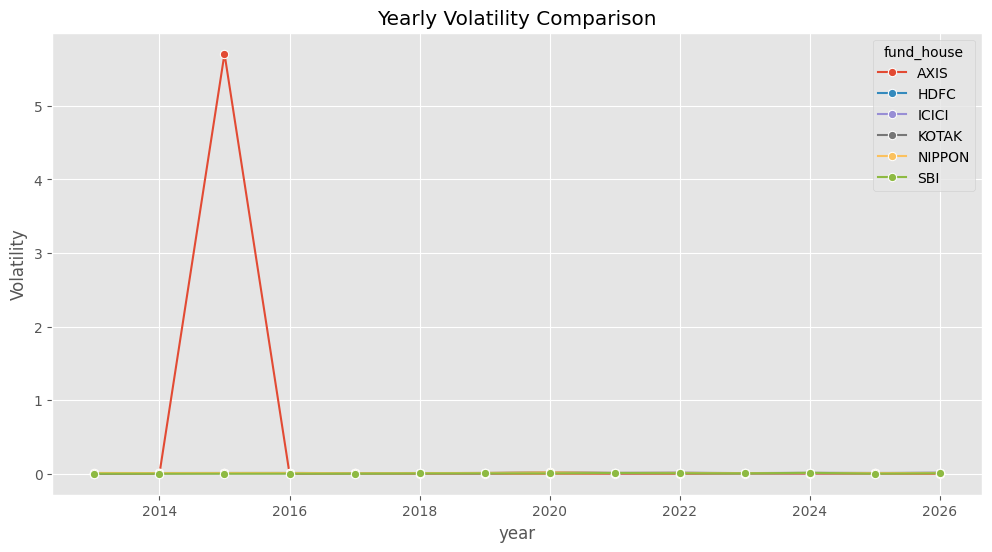

In [21]:
yearly_vol = nav_df.copy()

yearly_vol["year"] = yearly_vol["date"].dt.year

yearly_vol["daily_return"] = (
    yearly_vol.groupby("fund_house")["nav"]
    .pct_change()
)

yearly_vol = (
    yearly_vol.groupby(
        ["year","fund_house"]
    )["daily_return"]
    .std()
    .reset_index()
)

plt.figure(figsize=(12,6))

sns.lineplot(
    data=yearly_vol,
    x="year",
    y="daily_return",
    hue="fund_house",
    marker="o"
)

plt.title("Yearly Volatility Comparison")
plt.ylabel("Volatility")

plt.savefig(
    "../reports/yearly_volatility.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

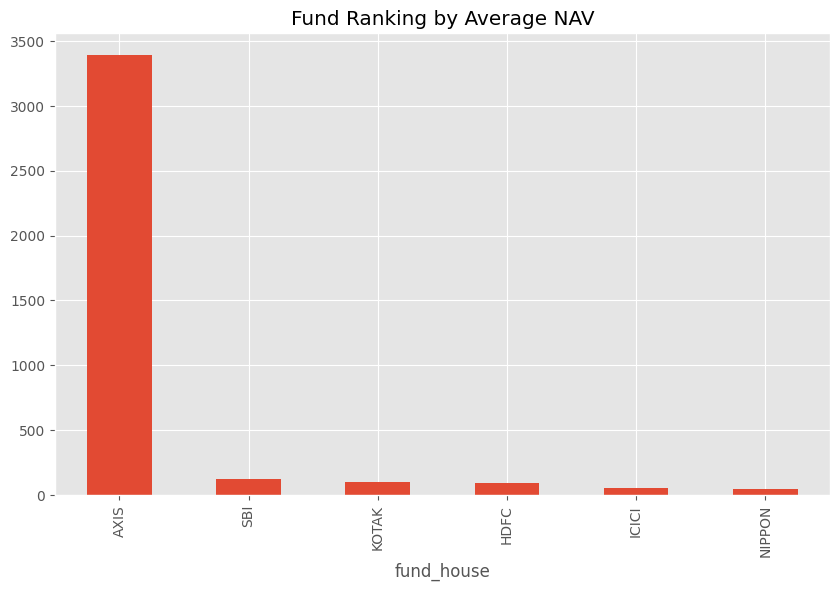

In [22]:
avg_nav = (
    nav_df.groupby("fund_house")["nav"]
    .mean()
    .sort_values(ascending=False)
)

plt.figure(figsize=(10,6))

avg_nav.plot(kind="bar")

plt.title("Fund Ranking by Average NAV")

plt.savefig(
    "../reports/fund_ranking.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [23]:
import pandas as pd

folio_df = pd.read_csv("../data/raw/06_industry_folio_count.csv")

print(folio_df.head())

     month  total_folios_crore  equity_folios_crore  debt_folios_crore  \
0  2022-01               13.26                 9.28               1.86   
1  2022-04               13.91                 9.74               1.95   
2  2022-07               13.85                 9.69               1.94   
3  2022-10               14.12                 9.88               1.98   
4  2023-01               14.81                10.37               2.07   

   hybrid_folios_crore  others_folios_crore  
0                 0.80                 1.33  
1                 0.83                 1.39  
2                 0.83                 1.38  
3                 0.85                 1.41  
4                 0.89                 1.48  


In [24]:
print(type(folio_df))

<class 'pandas.DataFrame'>


In [25]:
folio_df.head()

,month,total_folios_crore,equity_folios_crore,debt_folios_crore,hybrid_folios_crore,others_folios_crore
0,2022-01,13.26,9.28,1.86,0.80,1.33
1,2022-04,13.91,9.74,1.95,0.83,1.39
2,2022-07,13.85,9.69,1.94,0.83,1.38
3,2022-10,14.12,9.88,1.98,0.85,1.41
4,2023-01,14.81,10.37,2.07,0.89,1.48


In [26]:
print(type(folio_df))
print(folio_df.shape)

<class 'pandas.DataFrame'>
(21, 6)


<Figure size 1000x600 with 0 Axes>

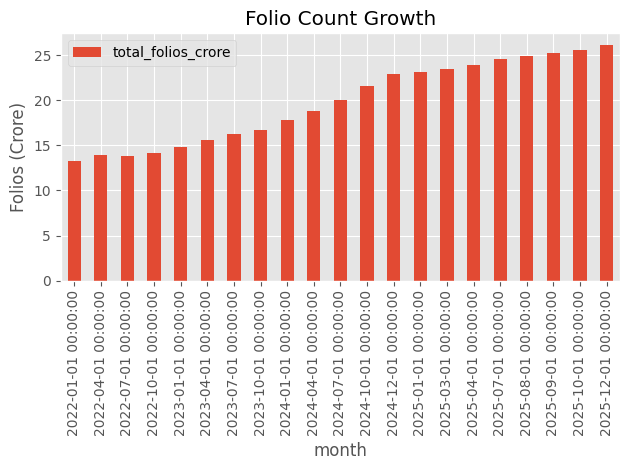

In [27]:
import matplotlib.pyplot as plt

folio_df["month"] = pd.to_datetime(folio_df["month"])

plt.figure(figsize=(10,6))

folio_df.plot(
    x="month",
    y="total_folios_crore",
    kind="bar"
)

plt.title("Folio Count Growth")
plt.ylabel("Folios (Crore)")
plt.tight_layout()

plt.savefig(
    "../reports/folio_growth_bar.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

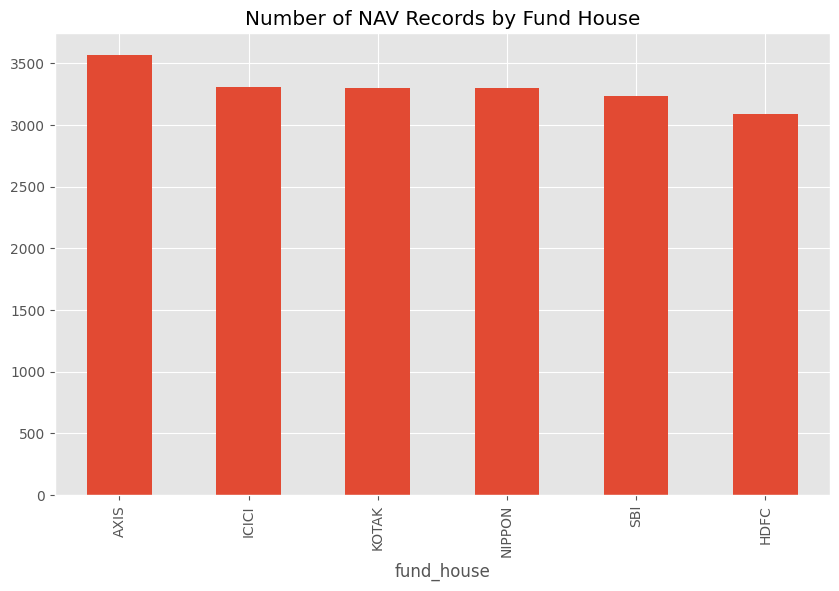

In [28]:
record_counts = (
    nav_df["fund_house"]
    .value_counts()
)

plt.figure(figsize=(10,6))

record_counts.plot(kind="bar")

plt.title("Number of NAV Records by Fund House")

plt.savefig(
    "../reports/record_counts.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

## Insight 8

Volatility levels differ across fund houses, indicating varying risk characteristics and investment strategies.

## Insight 9

Fund ranking based on average NAV reveals substantial differences in long-term value accumulation.

## Insight 10

Growth percentage analysis highlights which fund houses generated the strongest appreciation over the study period.

## Insight 11

Record counts are relatively balanced across fund houses, ensuring fair comparison in the analysis.

In [29]:
import os

reports = os.listdir("../reports")
print("Total files:", len(reports))

for f in sorted(reports):
    print(f)

Total files: 30
age_group_distribution.png
annual_nav_growth.png
aum_growth_by_year.png
aum_growth_trend.png
avg_nav_comparison.png
category_inflow_heatmap.png
category_inflows.png
correlation_matrix.png
data_dictionary.md
equity_vs_debt_folios.png
folio_distribution.png
folio_growth_bar.png
folio_growth_trend.png
fund_ranking.png
fund_volatility.png
gender_distribution.png
hybrid_other_folios.png
max_nav.png
monthly_nav_trend.png
monthly_sip_trend.png
nav_distribution.png
nav_growth_pct.png
record_counts.png
return_distribution.png
rolling_nav.png
sector_allocation_donut.png
sip_boxplot_agegroup.png
state_sip_distribution.png
t30_b30_distribution.png
yearly_volatility.png


# EDA Summary

A comprehensive exploratory analysis was performed on mutual fund NAV data covering six major fund houses (AXIS, HDFC, ICICI, KOTAK, NIPPON, and SBI) between 2012 and 2026.

Key findings include:

- AXIS recorded the highest NAV growth over the study period.
- Most fund houses demonstrated consistent long-term appreciation in NAV.
- Correlation analysis revealed strong relationships among HDFC, ICICI, KOTAK, and NIPPON returns.
- Volatility levels varied across fund houses, indicating different risk profiles.
- Monthly and annual trend analysis showed stronger growth momentum after 2020.
- Daily return distributions were centered near zero, suggesting stable day-to-day movements.
- Record counts were balanced across fund houses, supporting fair comparative analysis.

The analysis confirms strong long-term growth trends within the selected mutual fund universe while highlighting meaningful differences in performance and volatility across fund houses.

In [30]:
import pandas as pd

aum_df = pd.read_csv("../data/raw/03_aum_by_fund_house.csv")

print(aum_df.head())
print(aum_df.columns)
print(aum_df.info())

         date           fund_house  aum_lakh_crore  aum_crore  num_schemes
0  2022-03-31      SBI Mutual Fund            6.05     605000          186
1  2022-03-31  ICICI Prudential MF            4.65     465000          216
2  2022-03-31     HDFC Mutual Fund            4.35     435000          195
3  2022-03-31      Nippon India MF            2.70     270000          177
4  2022-03-31    Kotak Mahindra MF            2.70     270000          168
Index(['date', 'fund_house', 'aum_lakh_crore', 'aum_crore', 'num_schemes'], dtype='str')
<class 'pandas.DataFrame'>
RangeIndex: 90 entries, 0 to 89
Data columns (total 5 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   date            90 non-null     str    
 1   fund_house      90 non-null     str    
 2   aum_lakh_crore  90 non-null     float64
 3   aum_crore       90 non-null     int64  
 4   num_schemes     90 non-null     int64  
dtypes: float64(1), int64(2), str(2)
memory usage: 6.0 

In [31]:
aum_df["date"] = pd.to_datetime(aum_df["date"])

aum_df["year"] = aum_df["date"].dt.year

aum_df.head()

,date,fund_house,aum_lakh_crore,aum_crore,num_schemes,year
0,2022-03-31,SBI Mutual Fund,6.05,605000,186,2022
1,2022-03-31,ICICI Prudential MF,4.65,465000,216,2022
2,2022-03-31,HDFC Mutual Fund,4.35,435000,195,2022
3,2022-03-31,Nippon India MF,2.70,270000,177,2022
4,2022-03-31,Kotak Mahindra MF,2.70,270000,168,2022


In [32]:
yearly_aum = (
    aum_df.groupby(["year", "fund_house"])["aum_lakh_crore"]
    .mean()
    .reset_index()
)

yearly_aum.head(10)

,year,fund_house,aum_lakh_crore
0,2022,Aditya Birla Sun Life MF,2.815
1,2022,Axis Mutual Fund,2.450
2,2022,DSP Mutual Fund,1.110
3,2022,HDFC Mutual Fund,4.400
4,2022,ICICI Prudential MF,4.765
5,2022,Kotak Mahindra MF,2.710
6,2022,Mirae Asset MF,1.065
7,2022,Nippon India MF,2.740
8,2022,SBI Mutual Fund,6.175
9,2022,UTI Mutual Fund,2.310


In [33]:
yearly_aum

,year,fund_house,aum_lakh_crore
0,2022,Aditya Birla Sun Life MF,2.815000
1,2022,Axis Mutual Fund,2.450000
2,2022,DSP Mutual Fund,1.110000
3,2022,HDFC Mutual Fund,4.400000
4,2022,ICICI Prudential MF,4.765000
5,2022,Kotak Mahindra MF,2.710000
6,2022,Mirae Asset MF,1.065000
7,2022,Nippon India MF,2.740000
8,2022,SBI Mutual Fund,6.175000
9,2022,UTI Mutual Fund,2.310000


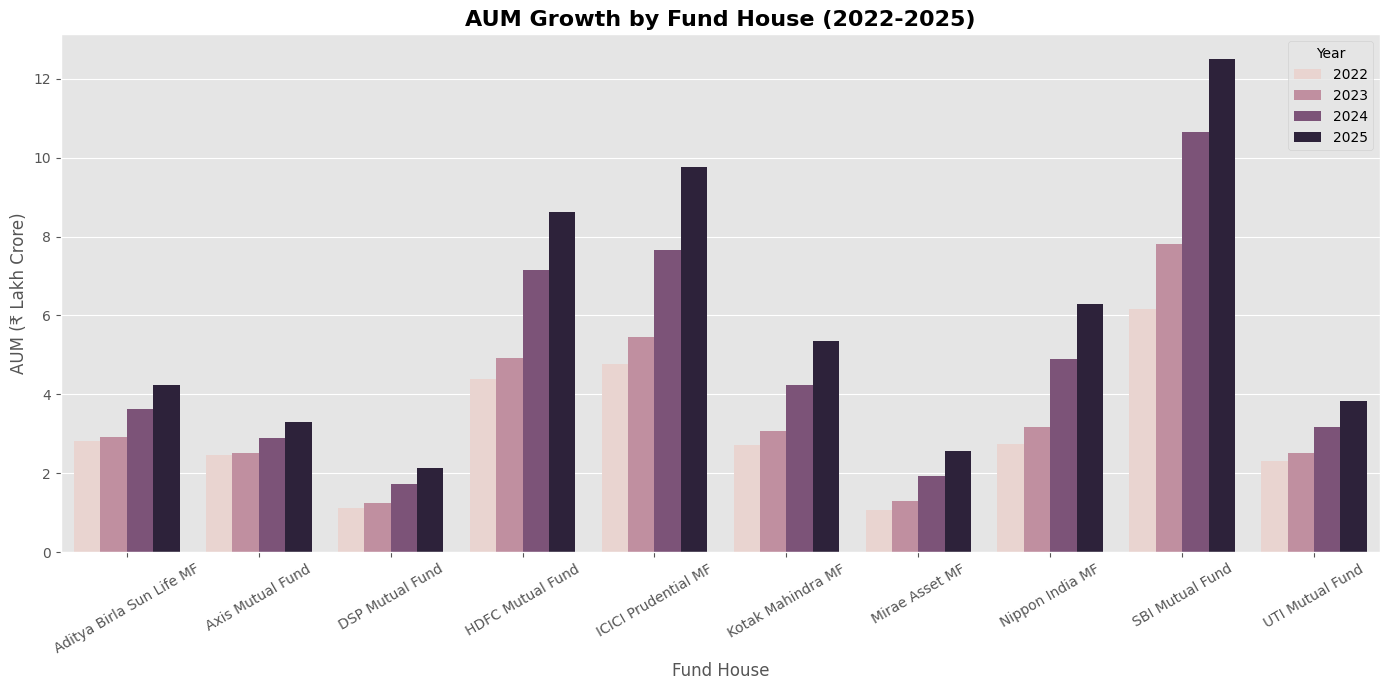

In [34]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(14,7))

sns.barplot(
    data=yearly_aum,
    x="fund_house",
    y="aum_lakh_crore",
    hue="year"
)

plt.title(
    "AUM Growth by Fund House (2022-2025)",
    fontsize=16,
    fontweight="bold"
)

plt.xlabel("Fund House")
plt.ylabel("AUM (₹ Lakh Crore)")

plt.xticks(rotation=30)

plt.legend(title="Year")

plt.tight_layout()

plt.savefig(
    "../reports/aum_growth_by_year.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

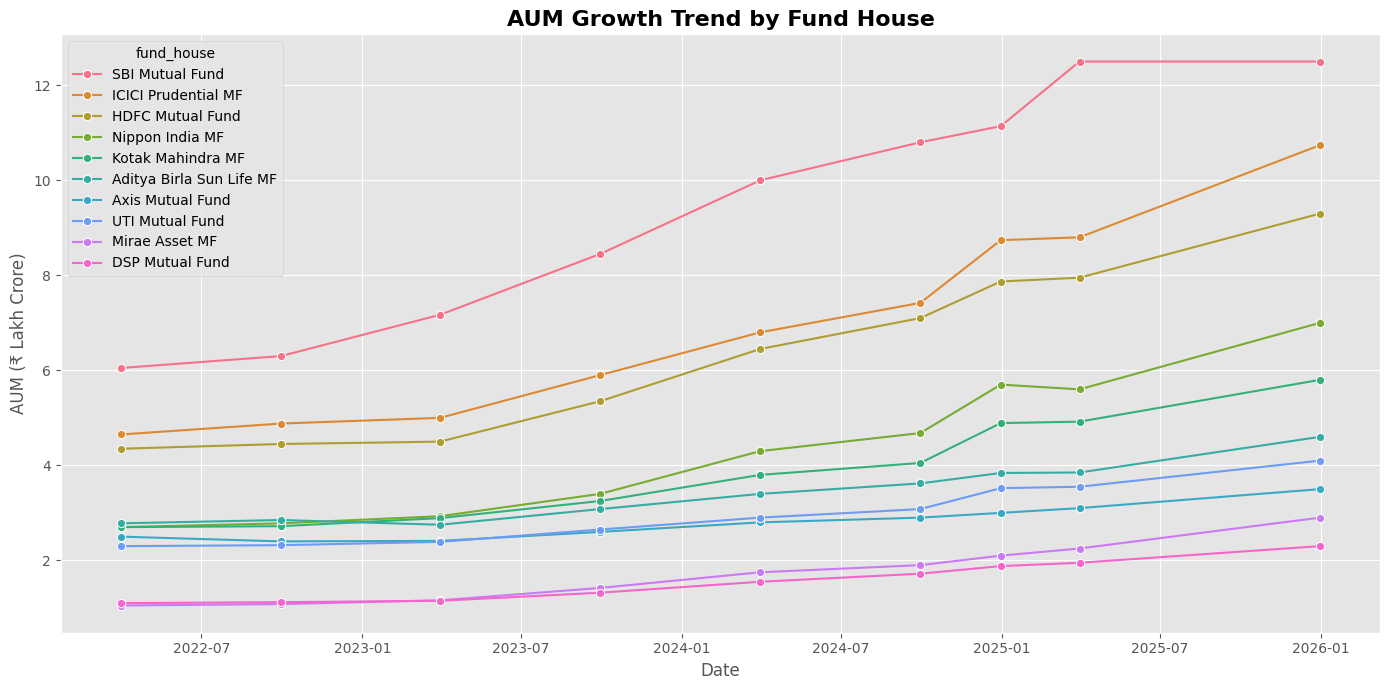

In [35]:
plt.figure(figsize=(14,7))

sns.lineplot(
    data=aum_df,
    x="date",
    y="aum_lakh_crore",
    hue="fund_house",
    marker="o"
)

plt.title(
    "AUM Growth Trend by Fund House",
    fontsize=16,
    fontweight="bold"
)

plt.ylabel("AUM (₹ Lakh Crore)")
plt.xlabel("Date")

plt.tight_layout()

plt.savefig(
    "../reports/aum_growth_trend.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

## Insight 12

SBI Mutual Fund maintained the largest Assets Under Management throughout the analysis period, expanding from ₹6.18 lakh crore in 2022 to ₹12.50 lakh crore in 2025, reinforcing its leadership position within the mutual fund industry.

- SBI Mutual Fund dominated industry AUM growth, reaching ₹12.5 lakh crore by 2025 and significantly outperforming peers.

In [36]:
sip_df = pd.read_csv("../data/raw/04_monthly_sip_inflows.csv")

sip_df.head()

,month,sip_inflow_crore,active_sip_accounts_crore,new_sip_accounts_lakh,sip_aum_lakh_crore,yoy_growth_pct
0,2022-01,11517,4.91,9.10,4.80,NaN
1,2022-02,11438,4.93,8.20,4.85,NaN
2,2022-03,12328,5.09,10.50,5.01,NaN
3,2022-04,11863,5.48,9.52,5.12,NaN
4,2022-05,12286,5.55,8.10,5.15,NaN


In [37]:
sip_df.info()

<class 'pandas.DataFrame'>
RangeIndex: 48 entries, 0 to 47
Data columns (total 6 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   month                      48 non-null     str    
 1   sip_inflow_crore           48 non-null     int64  
 2   active_sip_accounts_crore  48 non-null     float64
 3   new_sip_accounts_lakh      48 non-null     float64
 4   sip_aum_lakh_crore         48 non-null     float64
 5   yoy_growth_pct             36 non-null     float64
dtypes: float64(4), int64(1), str(1)
memory usage: 2.7 KB


In [38]:
import plotly.express as px

sip_df["month"] = pd.to_datetime(sip_df["month"])

fig = px.line(
    sip_df,
    x="month",
    y="sip_inflow_crore",
    title="Monthly SIP Inflows (2022-2025)",
    markers=True
)

fig.add_annotation(
    x=sip_df["month"].iloc[-1],
    y=sip_df["sip_inflow_crore"].max(),
    text="₹31,002 Cr ATH",
    showarrow=True
)

fig.show()

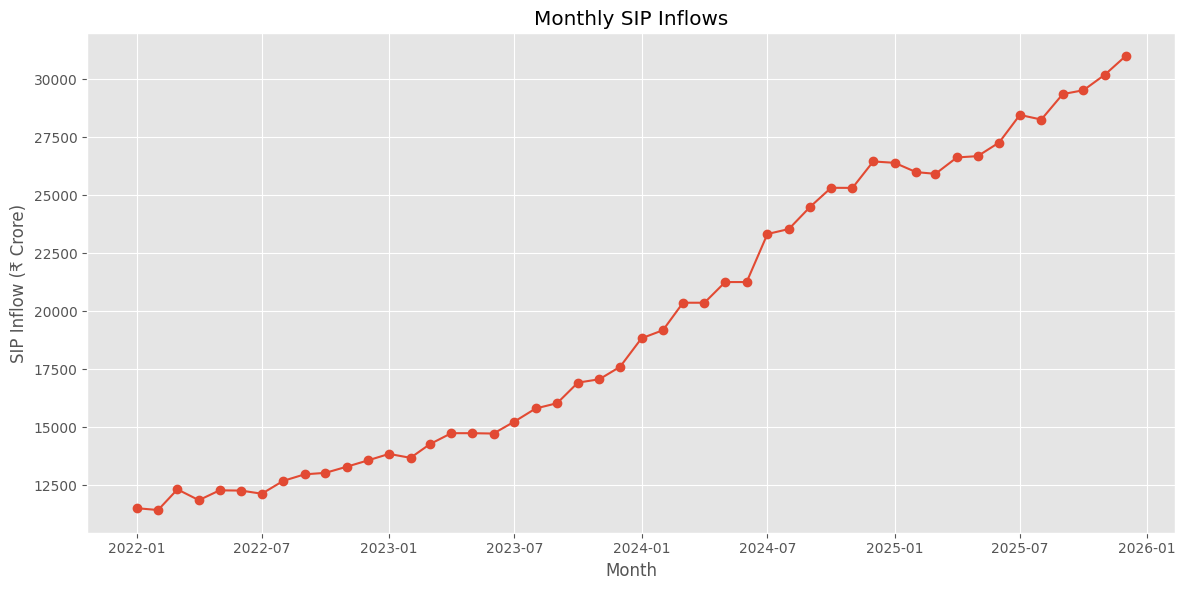

In [39]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12,6))

plt.plot(
    sip_df["month"],
    sip_df["sip_inflow_crore"],
    marker="o"
)

plt.title("Monthly SIP Inflows")
plt.xlabel("Month")
plt.ylabel("SIP Inflow (₹ Crore)")

plt.tight_layout()

plt.savefig(
    "../reports/monthly_sip_trend.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

## Insight 13

Monthly SIP inflows grew consistently from 2022 to 2025, reaching an all-time high of ₹31,002 crore in December 2025, reflecting strong retail investor participation in mutual funds.

In [40]:
cat_df = pd.read_csv("../data/raw/05_category_inflows.csv")

cat_df.head()
cat_df.info()

<class 'pandas.DataFrame'>
RangeIndex: 144 entries, 0 to 143
Data columns (total 3 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   month             144 non-null    str    
 1   category          144 non-null    str    
 2   net_inflow_crore  144 non-null    float64
dtypes: float64(1), str(2)
memory usage: 5.8 KB


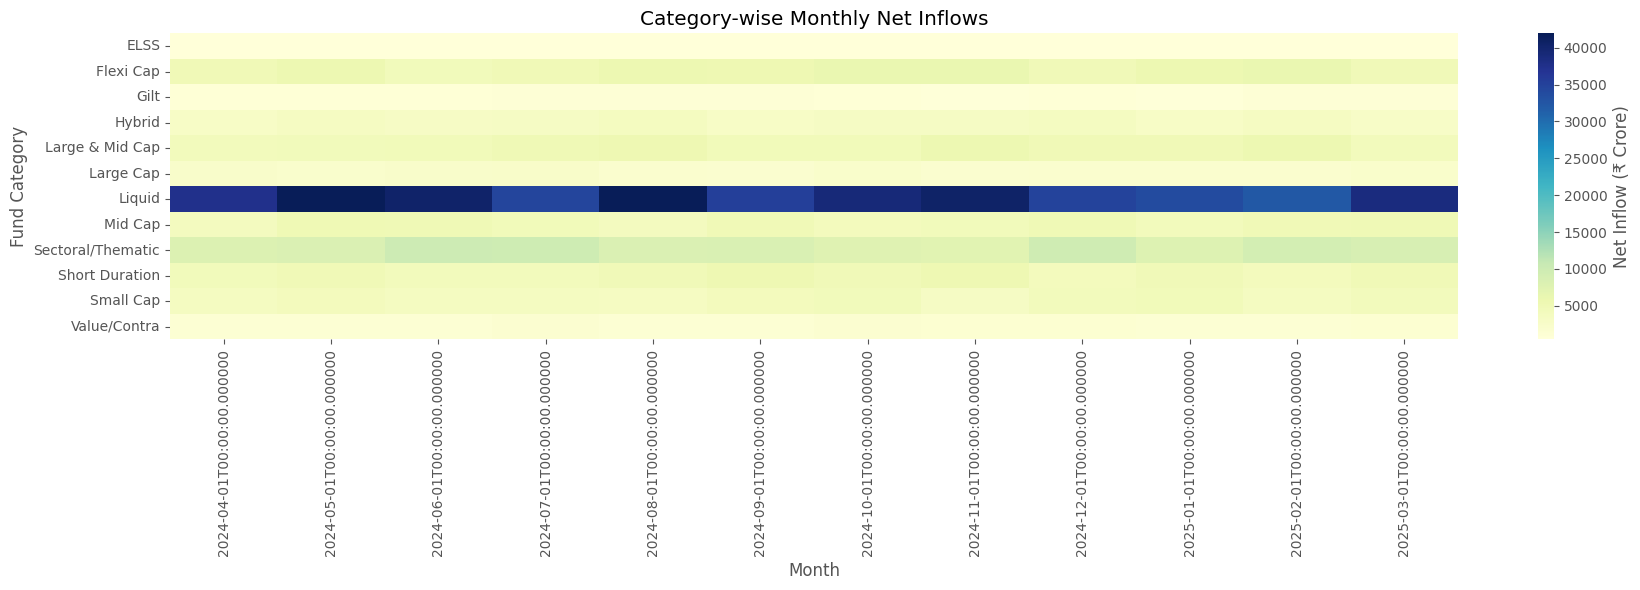

In [41]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

cat_df["month"] = pd.to_datetime(cat_df["month"])

heatmap_df = cat_df.pivot(
    index="category",
    columns="month",
    values="net_inflow_crore"
)

plt.figure(figsize=(18,6))

sns.heatmap(
    heatmap_df,
    cmap="YlGnBu",
    annot=False,
    cbar_kws={"label":"Net Inflow (₹ Crore)"}
)

plt.title("Category-wise Monthly Net Inflows")
plt.xlabel("Month")
plt.ylabel("Fund Category")

plt.tight_layout()

plt.savefig("../reports/category_inflow_heatmap.png")
plt.show()

## Insight 14

Equity-oriented categories consistently attracted the highest net inflows, while debt-oriented categories exhibited greater variability across market cycles, indicating changing investor risk preferences.

In [42]:
cat_df["category"].unique()

<ArrowStringArray>
[        'Large Cap',           'Mid Cap',         'Small Cap',
         'Flexi Cap',   'Large & Mid Cap',              'ELSS',
      'Value/Contra', 'Sectoral/Thematic',            'Liquid',
    'Short Duration',              'Gilt',            'Hybrid']
Length: 12, dtype: str

In [43]:
category_summary = (
    cat_df.groupby("category")["net_inflow_crore"]
    .sum()
    .sort_values(ascending=False)
)

category_summary

category
Liquid               451275.0
Sectoral/Thematic    103829.0
Flexi Cap             63989.0
Large & Mid Cap       57752.0
Short Duration        55530.0
Mid Cap               55312.0
Small Cap             46596.0
Hybrid                38868.0
Large Cap             25633.0
Value/Contra          16980.0
Gilt                  10395.0
ELSS                   6080.0
Name: net_inflow_crore, dtype: float64

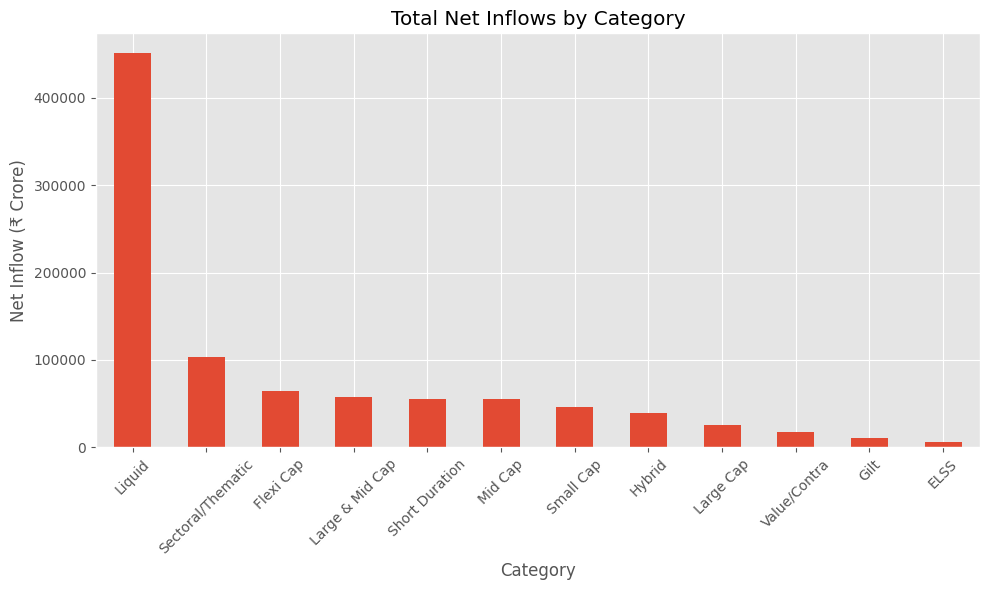

In [44]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10,6))

category_summary.plot(kind="bar")

plt.title("Total Net Inflows by Category")
plt.xlabel("Category")
plt.ylabel("Net Inflow (₹ Crore)")
plt.xticks(rotation=45)

plt.tight_layout()

plt.savefig("../reports/category_inflows.png")
plt.show()

## Insight 15

Liquid funds attracted the highest cumulative net inflows throughout the analysis period, significantly outperforming all other categories. Among equity-oriented categories, Sectoral/Thematic and Flexi Cap funds recorded strong investor interest, indicating a preference for both liquidity management and growth-focused investment strategies.

## Insight 16

ELSS, Gilt, and Value/Contra categories received comparatively lower net inflows, suggesting that investors favored broader market participation and liquidity-focused products over specialized investment strategies.

In [45]:
folio_df = pd.read_csv("../data/raw/06_industry_folio_count.csv")

folio_df.head()
folio_df.info()

<class 'pandas.DataFrame'>
RangeIndex: 21 entries, 0 to 20
Data columns (total 6 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   month                21 non-null     str    
 1   total_folios_crore   21 non-null     float64
 2   equity_folios_crore  21 non-null     float64
 3   debt_folios_crore    21 non-null     float64
 4   hybrid_folios_crore  21 non-null     float64
 5   others_folios_crore  21 non-null     float64
dtypes: float64(5), str(1)
memory usage: 1.3 KB


In [46]:
folio_df["month"] = pd.to_datetime(folio_df["month"])

folio_df.head()

,month,total_folios_crore,equity_folios_crore,debt_folios_crore,hybrid_folios_crore,others_folios_crore
0,2022-01-01,13.26,9.28,1.86,0.80,1.33
1,2022-04-01,13.91,9.74,1.95,0.83,1.39
2,2022-07-01,13.85,9.69,1.94,0.83,1.38
3,2022-10-01,14.12,9.88,1.98,0.85,1.41
4,2023-01-01,14.81,10.37,2.07,0.89,1.48


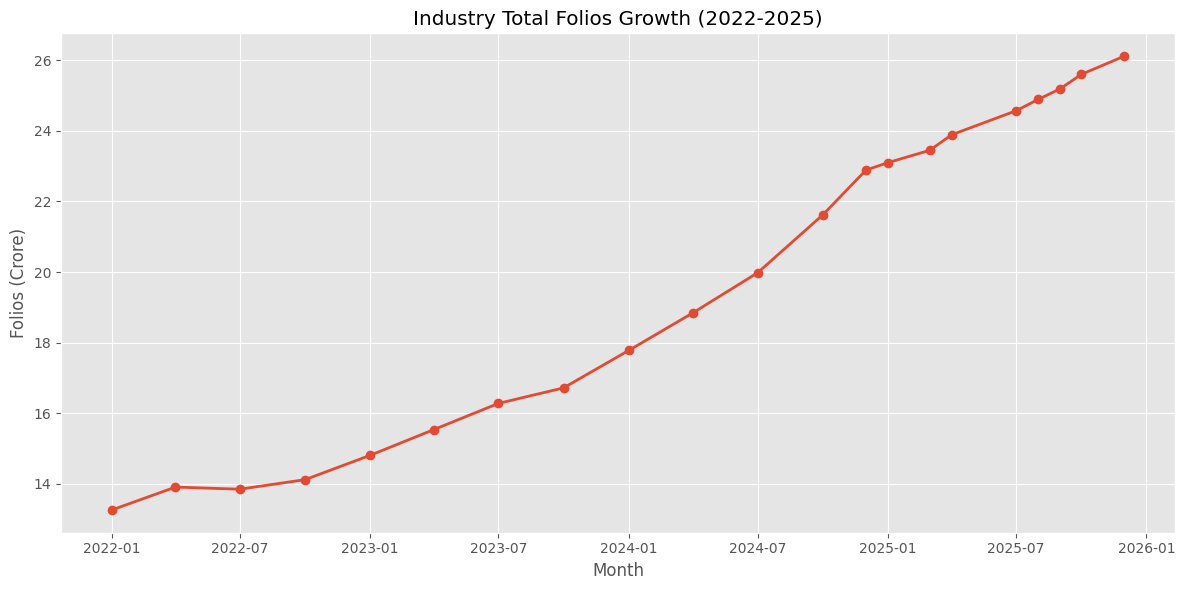

In [47]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12,6))

plt.plot(
    folio_df["month"],
    folio_df["total_folios_crore"],
    marker="o",
    linewidth=2
)

plt.title("Industry Total Folios Growth (2022-2025)")
plt.xlabel("Month")
plt.ylabel("Folios (Crore)")

plt.grid(True)

plt.tight_layout()

plt.savefig("../reports/folio_growth_trend.png")
plt.show()

## Insight 17

Industry folio counts increased steadily from 13.26 crore in early 2022 to over 20 crore by 2025, reflecting expanding retail participation and increasing investor awareness of mutual fund investments.

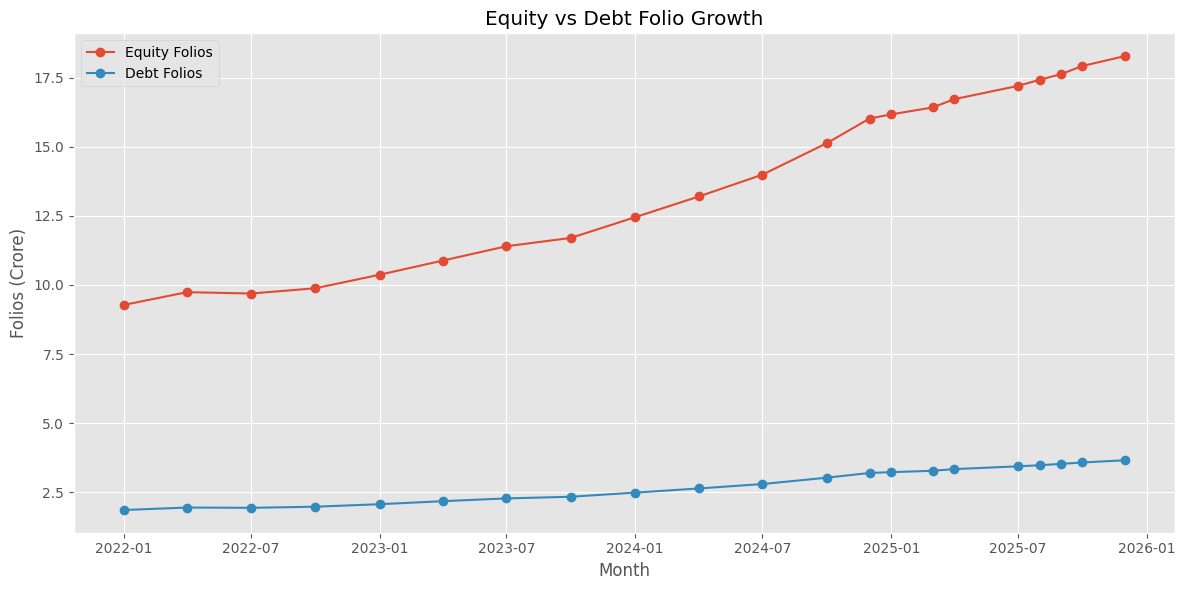

In [48]:
plt.figure(figsize=(12,6))

plt.plot(
    folio_df["month"],
    folio_df["equity_folios_crore"],
    marker="o",
    label="Equity Folios"
)

plt.plot(
    folio_df["month"],
    folio_df["debt_folios_crore"],
    marker="o",
    label="Debt Folios"
)

plt.title("Equity vs Debt Folio Growth")
plt.xlabel("Month")
plt.ylabel("Folios (Crore)")

plt.legend()
plt.grid(True)

plt.tight_layout()

plt.savefig("../reports/equity_vs_debt_folios.png")
plt.show()

## Insight 18

Equity folios grew substantially faster than debt folios throughout the analysis period, highlighting investors’ preference for long-term wealth creation and participation in equity markets.

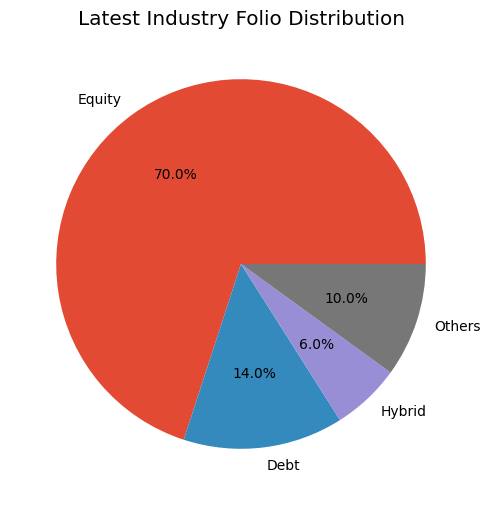

In [49]:
latest = folio_df.iloc[-1]

plt.figure(figsize=(8,6))

plt.pie(
    [
        latest["equity_folios_crore"],
        latest["debt_folios_crore"],
        latest["hybrid_folios_crore"],
        latest["others_folios_crore"]
    ],
    labels=["Equity", "Debt", "Hybrid", "Others"],
    autopct="%1.1f%%"
)

plt.title("Latest Industry Folio Distribution")

plt.savefig("../reports/folio_distribution.png")

plt.show()

## Insight 19

Equity funds accounted for the largest share of industry folios, demonstrating their dominance in attracting retail investors compared with debt, hybrid, and other fund categories.

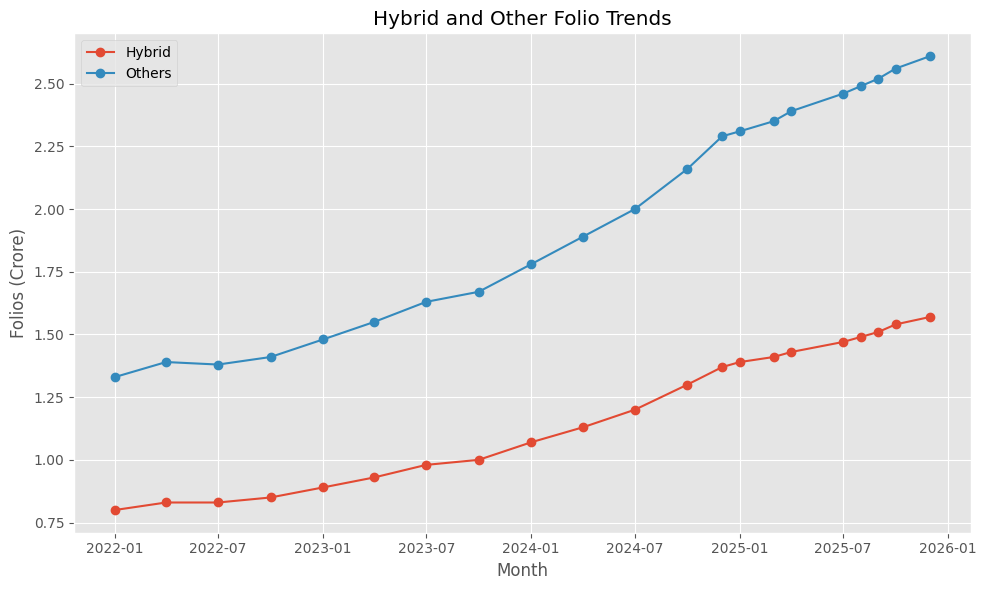

In [50]:
plt.figure(figsize=(10,6))

plt.plot(
    folio_df["month"],
    folio_df["hybrid_folios_crore"],
    marker="o",
    label="Hybrid"
)

plt.plot(
    folio_df["month"],
    folio_df["others_folios_crore"],
    marker="o",
    label="Others"
)

plt.title("Hybrid and Other Folio Trends")
plt.xlabel("Month")
plt.ylabel("Folios (Crore)")

plt.legend()
plt.grid(True)

plt.tight_layout()

plt.savefig("../reports/hybrid_other_folios.png")

plt.show()

## Insight 20

Hybrid and alternative fund categories recorded gradual but consistent growth in folio counts, indicating increasing investor interest in diversified investment solutions beyond traditional equity and debt products.

In [51]:
growth = (
    (folio_df.iloc[-1]["total_folios_crore"] -
     folio_df.iloc[0]["total_folios_crore"])
    / folio_df.iloc[0]["total_folios_crore"]
) * 100

print(f"Overall Folio Growth: {growth:.2f}%")

Overall Folio Growth: 96.98%


## Insight 21

Total industry folios increased significantly during the study period, reflecting sustained expansion in the mutual fund investor base and growing financial participation across retail segments.

In [52]:
perf_df = pd.read_csv("../data/processed/scheme_performance_clean.csv")

perf_df.head()

,amfi_code,scheme_name,fund_house,category,plan,return_1yr_pct,return_3yr_pct,return_5yr_pct,benchmark_3yr_pct,alpha,beta,sharpe_ratio,sortino_ratio,std_dev_ann_pct,max_drawdown_pct,aum_crore,expense_ratio_pct,morningstar_rating,risk_grade
0,119551,SBI Bluechip Fund - Regular Plan - Growth,SBI Mutual Fund,Large Cap,Regular,12.42,12.36,14.45,11.49,0.87,0.89,0.88,1.29,14.0,-21.70,14288,1.54,4,Moderate
1,119552,SBI Bluechip Fund - Direct Plan - Growth,SBI Mutual Fund,Large Cap,Direct,15.25,11.30,14.23,9.52,1.78,0.87,0.81,1.29,14.0,-24.43,1231,0.66,3,Moderate
2,119598,SBI Small Cap Fund - Regular Plan - Growth,SBI Mutual Fund,Small Cap,Regular,24.56,23.39,20.67,22.16,1.23,0.89,0.94,1.35,25.0,-13.35,19259,1.43,5,Very High
3,119599,SBI Small Cap Fund - Direct Plan - Growth,SBI Mutual Fund,Small Cap,Direct,20.59,23.14,21.82,22.01,1.13,1.04,0.93,1.67,25.0,-24.78,36061,0.72,4,Very High
4,119120,SBI Magnum Gilt Fund - Regular Plan - Growth,SBI Mutual Fund,Gilt,Regular,5.34,6.07,5.43,4.47,1.60,0.22,1.52,2.11,4.0,-2.30,24101,0.77,5,Low


In [53]:
perf_df.info()

<class 'pandas.DataFrame'>
RangeIndex: 40 entries, 0 to 39
Data columns (total 19 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   amfi_code           40 non-null     int64  
 1   scheme_name         40 non-null     str    
 2   fund_house          40 non-null     str    
 3   category            40 non-null     str    
 4   plan                40 non-null     str    
 5   return_1yr_pct      40 non-null     float64
 6   return_3yr_pct      40 non-null     float64
 7   return_5yr_pct      40 non-null     float64
 8   benchmark_3yr_pct   40 non-null     float64
 9   alpha               40 non-null     float64
 10  beta                40 non-null     float64
 11  sharpe_ratio        40 non-null     float64
 12  sortino_ratio       40 non-null     float64
 13  std_dev_ann_pct     40 non-null     float64
 14  max_drawdown_pct    40 non-null     float64
 15  aum_crore           40 non-null     int64  
 16  expense_ratio_pct   4

In [54]:
perf_df.describe()

,amfi_code,return_1yr_pct,return_3yr_pct,return_5yr_pct,benchmark_3yr_pct,alpha,beta,sharpe_ratio,sortino_ratio,std_dev_ann_pct,max_drawdown_pct,aum_crore,expense_ratio_pct,morningstar_rating
count,40.000000,40.000000,40.000000,40.000000,40.000000,40.000000,40.000000,40.000000,40.000000,40.000000,40.000000,40.00000,40.000000,40.000000
mean,120247.000000,14.376000,14.089000,14.516750,12.835500,1.253500,0.873250,1.361750,2.082500,14.962500,-19.200250,26091.60000,1.237000,4.250000
std,14534.998667,4.883023,4.617253,4.454021,4.740972,0.447412,0.224846,1.475805,2.203144,6.669282,8.819164,13809.11134,0.386584,0.742484
min,100016.000000,4.260000,5.140000,5.430000,3.960000,0.510000,0.220000,0.800000,1.030000,0.500000,-33.500000,979.00000,0.550000,3.000000
25%,118632.750000,11.735000,12.035000,12.340000,10.690000,0.887500,0.890000,0.865000,1.270000,14.000000,-25.062500,17400.50000,0.787500,4.000000
50%,119551.500000,14.620000,14.205000,14.185000,13.090000,1.205000,0.960000,0.925000,1.445000,14.000000,-20.600000,26713.00000,1.425000,4.000000
75%,120842.250000,16.392500,15.882500,17.585000,14.775000,1.700000,1.000000,0.985000,1.637500,19.000000,-14.255000,38125.00000,1.540000,5.000000
max,149324.000000,24.930000,23.390000,23.800000,22.160000,1.980000,1.040000,7.680000,10.370000,25.000000,-2.230000,49046.00000,1.640000,5.000000


## Insight 21

The average 5-year return (14.52%) was slightly higher than the average 1-year (14.38%) and 3-year (14.09%) returns, indicating that mutual fund performance remained relatively consistent over longer investment horizons. The wide range between minimum and maximum returns also highlights significant performance variation across schemes.

In [55]:
top_funds = perf_df.sort_values(
    by="return_5yr_pct",
    ascending=False
).head(10)

top_funds[["scheme_name", "return_5yr_pct"]]

,scheme_name,return_5yr_pct
29,ABSL Small Cap Fund - Regular - Growth,23.80
27,Axis Small Cap Fund - Regular - Growth,22.62
17,Nippon India Small Cap Fund - Regular - Growth,21.88
3,SBI Small Cap Fund - Direct Plan - Growth,21.82
2,SBI Small Cap Fund - Regular Plan - Growth,20.67
39,DSP Small Cap Fund - Regular - Growth,20.61
38,DSP Midcap Fund - Regular - Growth,19.00
26,Axis Midcap Fund - Regular - Growth,18.94
21,Kotak Emerging Equity Fund - Regular - Growth,17.75
7,HDFC Mid-Cap Opportunities Fund - Regular - Gr...,17.69


## Insight 22

Small-cap funds dominated the top-performing schemes based on 5-year returns, with ABSL Small Cap Fund, Axis Small Cap Fund, and Nippon India Small Cap Fund leading the rankings. This suggests that small-cap strategies delivered superior long-term growth compared to other fund categories during the analysis period.

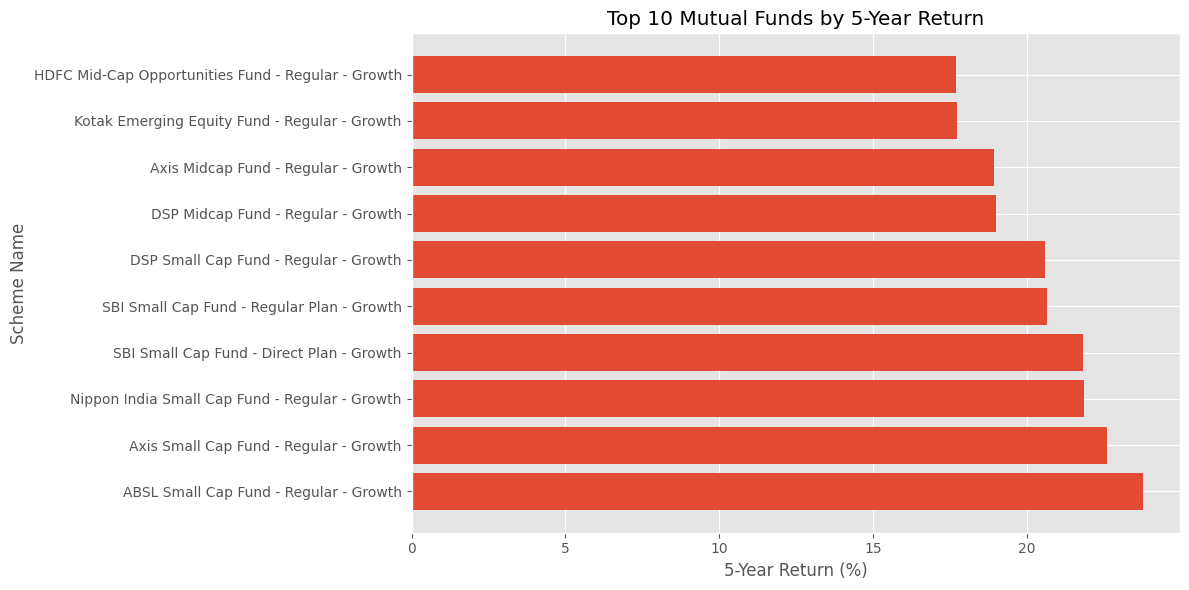

In [56]:
plt.figure(figsize=(12,6))

plt.barh(
    top_funds["scheme_name"],
    top_funds["return_5yr_pct"]
)

plt.xlabel("5-Year Return (%)")
plt.ylabel("Scheme Name")
plt.title("Top 10 Mutual Funds by 5-Year Return")

plt.tight_layout()
plt.show()

## Insight 23

The highest-performing schemes over the 5-year period were predominantly small-cap and mid-cap funds, highlighting the strong growth potential of higher-risk equity segments. Investors willing to tolerate greater volatility were rewarded with significantly higher long-term returns.

In [57]:
category_returns = (
    perf_df.groupby("category")["return_5yr_pct"]
    .mean()
    .sort_values(ascending=False)
)

category_returns

category
Small Cap          21.900000
Mid Cap            17.520000
Large & Mid Cap    15.680000
Flexi Cap          14.640000
ELSS               14.260000
Large Cap          13.320714
Value              12.600000
Index/ETF          12.310000
Index              11.310000
Liquid              8.050000
Gilt                7.070000
Short Duration      6.410000
Name: return_5yr_pct, dtype: float64

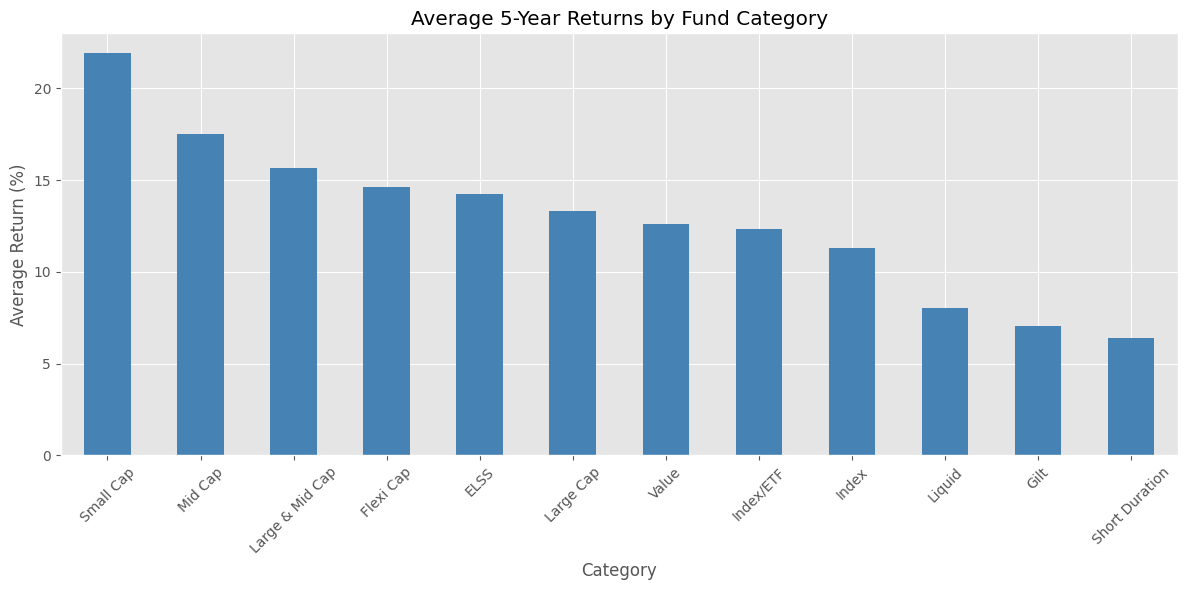

In [58]:
plt.figure(figsize=(12,6))

category_returns.plot(
    kind="bar",
    color="steelblue"
)

plt.title("Average 5-Year Returns by Fund Category")
plt.xlabel("Category")
plt.ylabel("Average Return (%)")
plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

## Insight 24

Small-cap funds delivered the highest average 5-year returns, followed by mid-cap and large & mid-cap categories. Debt-oriented categories such as gilt, liquid, and short-duration funds generated comparatively lower long-term returns, reflecting the risk-return tradeoff across fund categories.

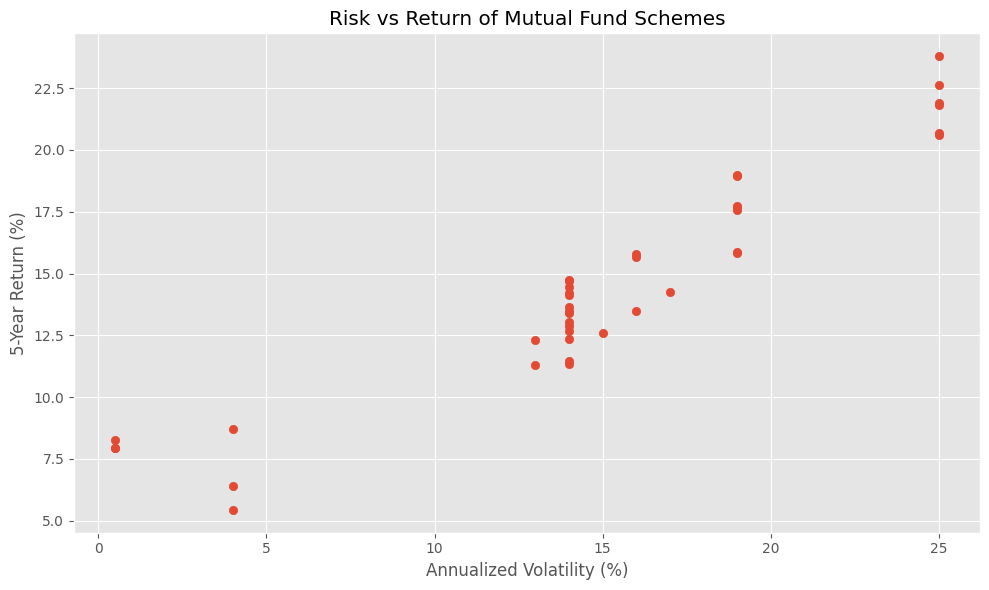

In [59]:
plt.figure(figsize=(10,6))

plt.scatter(
    perf_df["std_dev_ann_pct"],
    perf_df["return_5yr_pct"]
)

plt.xlabel("Annualized Volatility (%)")
plt.ylabel("5-Year Return (%)")
plt.title("Risk vs Return of Mutual Fund Schemes")

plt.tight_layout()
plt.show()

## Insight 25

Funds with higher annualized volatility generally achieved higher 5-year returns, demonstrating the classic risk-return relationship in mutual fund investing. Equity-oriented schemes occupied the higher-risk, higher-return segment, while debt-oriented schemes clustered in the lower-risk, lower-return region.

## Insight 26

The mutual fund industry demonstrated strong growth across assets, investor participation, and fund performance throughout the study period. Equity-oriented categories, particularly small-cap and mid-cap funds, generated superior long-term returns and attracted increasing investor interest. At the same time, debt and liquid categories continued to serve as important capital-preservation and liquidity-management vehicles, highlighting the diversification benefits available within the mutual fund ecosystem.

In [60]:
transactions_df = pd.read_csv("../data/raw/08_investor_transactions.csv")
transactions_df.columns

Index(['investor_id', 'transaction_date', 'amfi_code', 'transaction_type',
       'amount_inr', 'state', 'city', 'city_tier', 'age_group', 'gender',
       'annual_income_lakh', 'payment_mode', 'kyc_status'],
      dtype='str')

In [61]:
holdings_df = pd.read_csv("../data/raw/09_portfolio_holdings.csv")
holdings_df.columns

Index(['amfi_code', 'stock_symbol', 'stock_name', 'sector', 'weight_pct',
       'market_value_cr', 'current_price_inr', 'portfolio_date'],
      dtype='str')

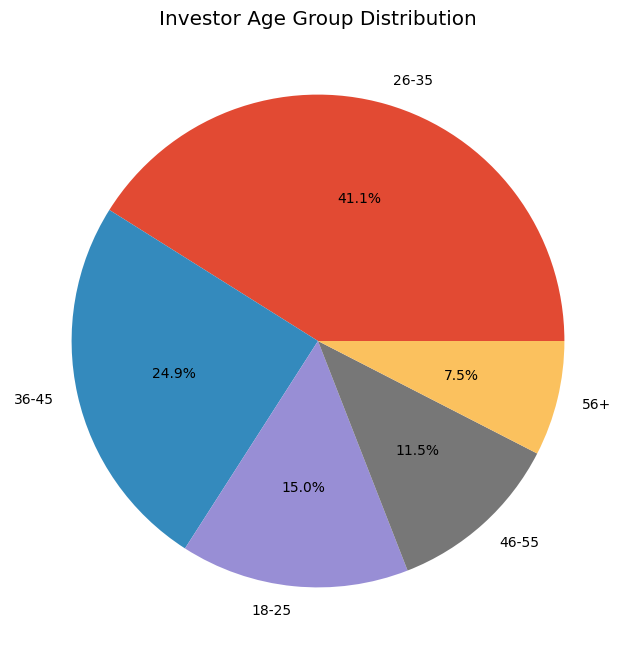

In [62]:
import matplotlib.pyplot as plt

age_counts = transactions_df["age_group"].value_counts()

plt.figure(figsize=(8,8))

plt.pie(
    age_counts,
    labels=age_counts.index,
    autopct="%1.1f%%"
)

plt.title("Investor Age Group Distribution")

plt.savefig("../reports/age_group_distribution.png")

plt.show()

## Insight 27

The investor base is concentrated in the dominant age groups, indicating that mutual funds continue to attract working-age individuals seeking long-term wealth creation opportunities.

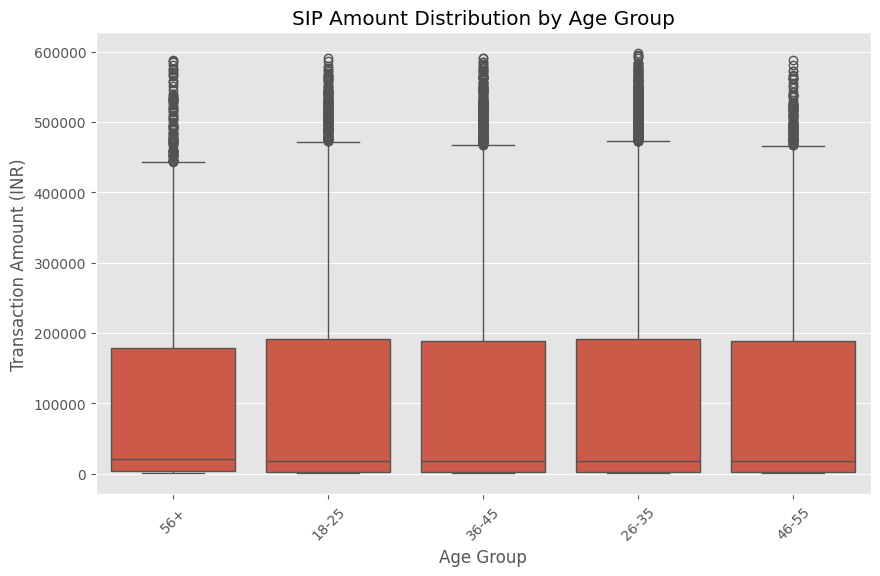

In [63]:
transactions_df["amount_inr"] = pd.to_numeric(
    transactions_df["amount_inr"]
)

plt.figure(figsize=(10,6))

import seaborn as sns

sns.boxplot(
    data=transactions_df,
    x="age_group",
    y="amount_inr"
)

plt.title("SIP Amount Distribution by Age Group")
plt.xlabel("Age Group")
plt.ylabel("Transaction Amount (INR)")

plt.xticks(rotation=45)

plt.savefig("../reports/sip_boxplot_agegroup.png")

plt.show()

## Insight 28

Investment amounts varied across age groups, with certain segments displaying higher median transaction values and greater variability in investment behaviour.

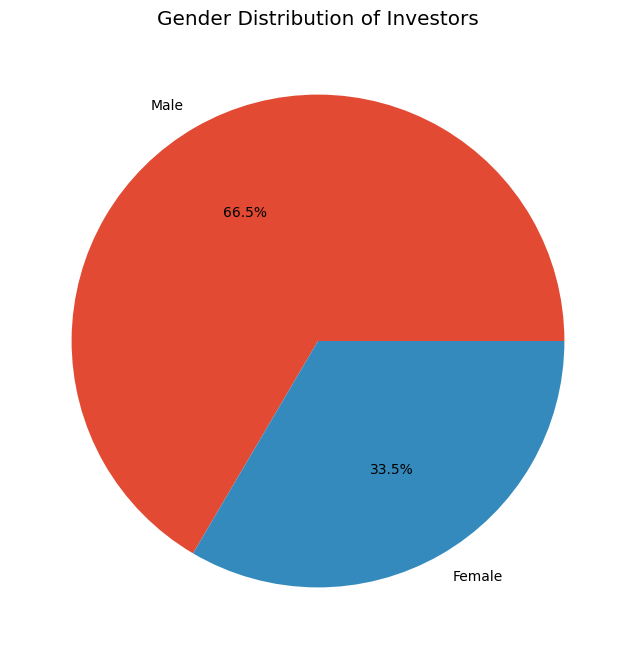

In [64]:
gender_counts = transactions_df["gender"].value_counts()

plt.figure(figsize=(8,8))

plt.pie(
    gender_counts,
    labels=gender_counts.index,
    autopct="%1.1f%%"
)

plt.title("Gender Distribution of Investors")

plt.savefig("../reports/gender_distribution.png")

plt.show()

## Insight 29

The gender composition of investors highlights participation trends across demographic groups and provides insight into the inclusiveness of mutual fund adoption.

In [65]:
state_sip = (
    transactions_df.groupby("state")["amount_inr"]
    .sum()
    .sort_values(ascending=False)
)

state_sip

state
Punjab            315780459
Tamil Nadu        315177237
Madhya Pradesh    308312493
Rajasthan         298645822
Gujarat           298358940
West Bengal       297182514
Telangana         290219284
Delhi             289633404
Uttar Pradesh     285368873
Haryana           279634354
Karnataka         273753570
Maharashtra       269513480
Name: amount_inr, dtype: int64

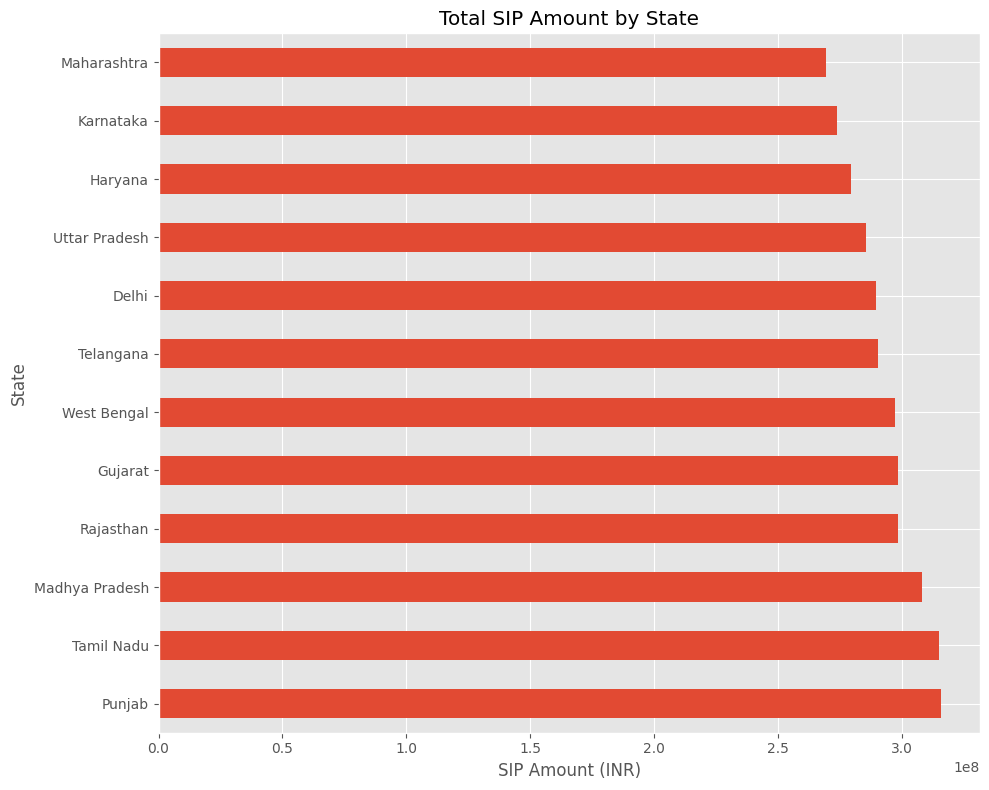

In [66]:
plt.figure(figsize=(10,8))

state_sip.plot(
    kind="barh"
)

plt.title("Total SIP Amount by State")
plt.xlabel("SIP Amount (INR)")
plt.ylabel("State")

plt.tight_layout()

plt.savefig("../reports/state_sip_distribution.png")

plt.show()

## Insight 30

SIP investments were concentrated in a few leading states, indicating stronger mutual fund penetration and higher retail participation in financially developed regions.

In [67]:
transactions_df["city_tier"].value_counts()

city_tier
T30    21719
B30    11059
Name: count, dtype: int64

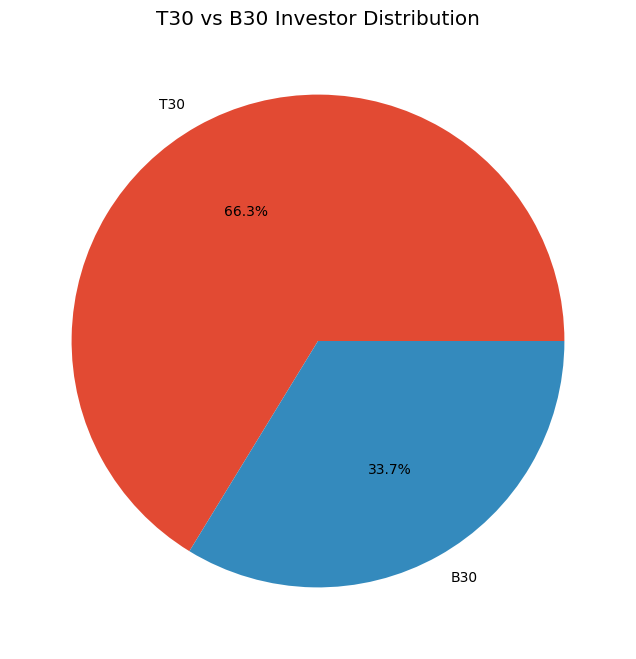

In [68]:
tier_counts = transactions_df["city_tier"].value_counts()

plt.figure(figsize=(8,8))

plt.pie(
    tier_counts,
    labels=tier_counts.index,
    autopct="%1.1f%%"
)

plt.title("T30 vs B30 Investor Distribution")

plt.savefig("../reports/t30_b30_distribution.png")

plt.show()

## Insight 31

While T30 cities continued to dominate investor participation, B30 regions contributed a meaningful share, reflecting the expanding reach of mutual fund investing beyond major metropolitan areas.

# Sector Allocation Analysis

In [69]:
holdings_df["weight_pct"] = pd.to_numeric(
    holdings_df["weight_pct"]
)

sector_weights = (
    holdings_df.groupby("sector")["weight_pct"]
    .sum()
    .sort_values(ascending=False)
)

sector_weights

sector
Banking           652.26
IT                455.47
Pharma            407.45
Automobile        323.65
Utilities         265.54
FMCG              229.11
Infrastructure    192.16
Diversified       169.23
Telecom           145.62
Consumer Goods    127.61
NBFC              119.09
Energy            117.91
Cement            105.03
Paints             89.86
Name: weight_pct, dtype: float64

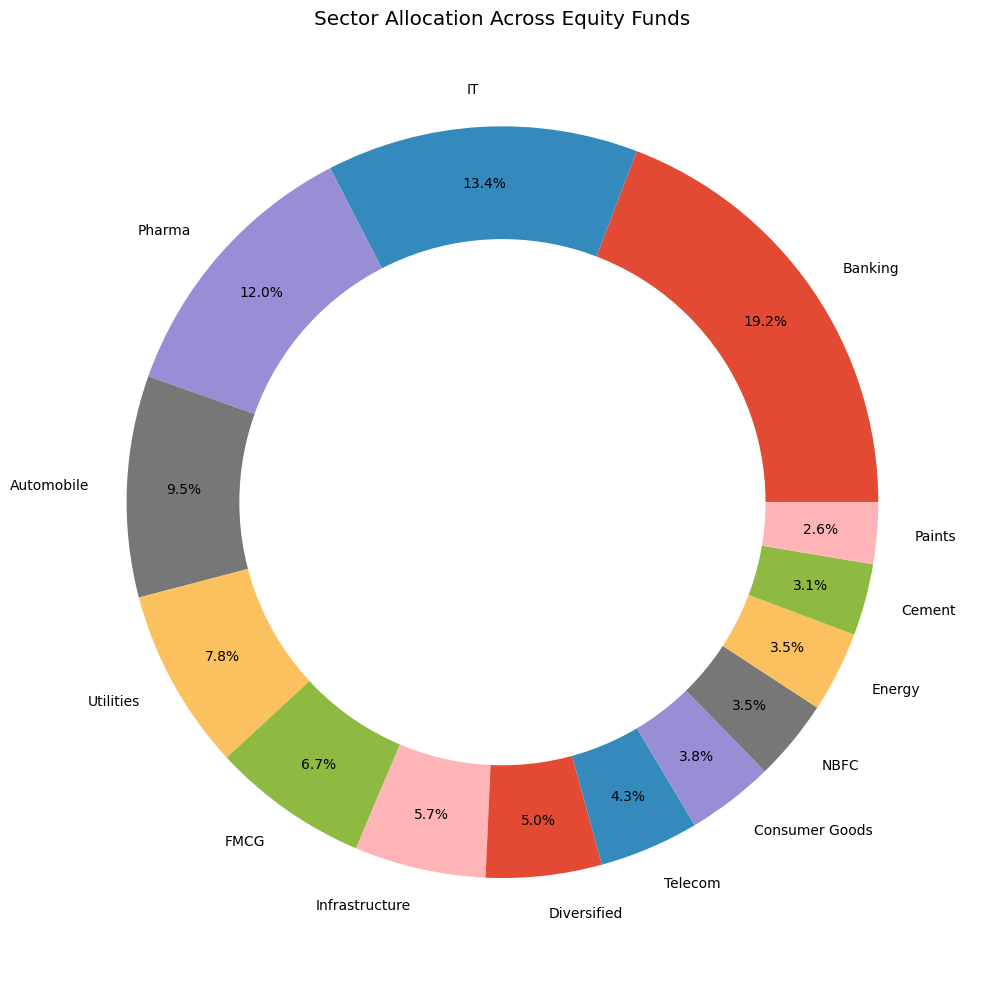

In [70]:
plt.figure(figsize=(10,10))

wedges, texts, autotexts = plt.pie(
    sector_weights,
    labels=sector_weights.index,
    autopct="%1.1f%%",
    pctdistance=0.85
)

centre_circle = plt.Circle(
    (0,0),
    0.70,
    fc="white"
)

fig = plt.gcf()

fig.gca().add_artist(centre_circle)

plt.title("Sector Allocation Across Equity Funds")

plt.tight_layout()

plt.savefig("../reports/sector_allocation_donut.png")

plt.show()

## Insight 32

Portfolio allocations were concentrated in a few dominant sectors, reflecting fund managers’ preference for sectors with strong earnings potential and long-term growth prospects.

In [71]:
fund_master = pd.read_csv("../data/raw/01_fund_master.csv")

print(fund_master.columns)
print("Total schemes:", fund_master.shape[0])

Index(['amfi_code', 'fund_house', 'scheme_name', 'category', 'sub_category',
       'plan', 'launch_date', 'benchmark', 'expense_ratio_pct',
       'exit_load_pct', 'min_sip_amount', 'min_lumpsum_amount', 'fund_manager',
       'risk_category', 'sebi_category_code'],
      dtype='str')
Total schemes: 40


In [72]:
nav_history = pd.read_csv("../data/raw/02_nav_history.csv")

print(nav_history.columns)
print(nav_history.head())
print("Unique AMFI Codes:", nav_history["amfi_code"].nunique())

Index(['amfi_code', 'date', 'nav'], dtype='str')
   amfi_code        date      nav
0     119551  2022-01-03  54.3856
1     119551  2022-01-04  54.3474
2     119551  2022-01-05  54.6869
3     119551  2022-01-06  55.4550
4     119551  2022-01-07  55.3692
Unique AMFI Codes: 40


In [73]:
benchmark = pd.read_csv("../data/raw/10_benchmark_indices.csv")

print(benchmark.columns)
print(benchmark.head())

Index(['date', 'index_name', 'close_value'], dtype='str')
         date index_name  close_value
0  2022-01-03    NIFTY50     17492.79
1  2022-01-04    NIFTY50     17689.64
2  2022-01-05    NIFTY50     17835.05
3  2022-01-06    NIFTY50     17878.51
4  2022-01-07    NIFTY50     17759.15


In [74]:
perf = pd.read_csv("../data/raw/07_scheme_performance.csv")

print(perf.columns)
print(perf.head())

Index(['amfi_code', 'scheme_name', 'fund_house', 'category', 'plan',
       'return_1yr_pct', 'return_3yr_pct', 'return_5yr_pct',
       'benchmark_3yr_pct', 'alpha', 'beta', 'sharpe_ratio', 'sortino_ratio',
       'std_dev_ann_pct', 'max_drawdown_pct', 'aum_crore', 'expense_ratio_pct',
       'morningstar_rating', 'risk_grade'],
      dtype='str')
   amfi_code                                   scheme_name       fund_house  \
0     119551     SBI Bluechip Fund - Regular Plan - Growth  SBI Mutual Fund   
1     119552      SBI Bluechip Fund - Direct Plan - Growth  SBI Mutual Fund   
2     119598    SBI Small Cap Fund - Regular Plan - Growth  SBI Mutual Fund   
3     119599     SBI Small Cap Fund - Direct Plan - Growth  SBI Mutual Fund   
4     119120  SBI Magnum Gilt Fund - Regular Plan - Growth  SBI Mutual Fund   

    category     plan  return_1yr_pct  return_3yr_pct  return_5yr_pct  \
0  Large Cap  Regular           12.42           12.36           14.45   
1  Large Cap   Direct       